# A Grounded Retrieval-Augmented Generation Pipeline for a Bilingual Document Corpus

**Design, implementation and empirical evaluation of a hybrid-retrieval RAG system with calibrated abstention.**

---

## Abstract

Retrieval-Augmented Generation grounds a language model's output in an external document
collection instead of its parametric memory. The naive formulation — embed, search, prompt —
is easy to build and difficult to trust: it retrieves poorly on lexical queries, degrades badly
across languages, cannot say where an answer came from, and, most damagingly, answers
confidently when the corpus contains no answer at all.

This notebook builds a complete pipeline that addresses each of those failures, and measures
whether each component earns its place. The corpus is deliberately bilingual — one English and
one Vietnamese technical document — because cross-lingual retrieval exposes weaknesses that a
monolingual benchmark hides.

The system combines multilingual dense retrieval, BM25 over word-segmented Vietnamese, rank
fusion, cross-encoder reranking, LLM-written chunk contextualisation, query decomposition, an
iterative retrieve–grade–rewrite loop, span-level citations, and a **calibrated abstention gate**
that is fitted on a held-out set of out-of-domain questions so the system declines to answer
what it cannot support.

Every design decision is stated as a hypothesis and tested. Results are reported as ablations
over retrieval configurations (recall@5, MRR@10, split by language), as an abstention decision
analysis (score separation, threshold sweep, confusion matrix on held-out data), and as an
end-to-end RAGAS evaluation (faithfulness, answer relevancy, context precision, context recall).

## Research questions

**RQ1.** How much retrieval accuracy is lost when a monolingual encoder is applied to a
bilingual corpus, and does a multilingual encoder recover it?

**RQ2.** Does lexical retrieval still contribute once a strong multilingual dense encoder is in
place, and does Vietnamese word segmentation matter for the lexical half?

**RQ3.** What is the marginal contribution of cross-encoder reranking over fused first-stage
retrieval?

**RQ4.** Does prepending LLM-written context to each chunk before embedding improve recall
beyond a deterministic structural prefix?

**RQ5.** Can a retrieval-score threshold, calibrated on held-out data, reliably separate
answerable from unanswerable questions — and what is the cost in false abstentions?

**RQ6.** Does an iterative retrieve–grade–rewrite loop recover answers that a single-shot
pipeline misses?

## Pipeline

```text
                         OFFLINE  (indexing)
  ┌──────────────────────────────────────────────────────────────────┐
  │  PDF / DOCX / TXT / CSV                                          │
  │        │                                                         │
  │        ▼                                                         │
  │  §3 Ingestion ─────────── one record per page, provenance kept   │
  │        ▼                                                         │
  │  §4 Normalisation ─────── running headers and footers removed    │
  │        ▼                                                         │
  │  §5 Chunking ──────────── token-budgeted, overlapping            │
  │        ▼                                                         │
  │  §6 Contextualisation ─── structural prefix + LLM-written context│
  │        ▼                                                         │
  │  §7 Dense index (BGE-M3)     §8 Sparse index (BM25 + pyvi)       │
  └──────────────────────────────────────────────────────────────────┘

                          ONLINE  (answering)
  ┌──────────────────────────────────────────────────────────────────┐
  │  question                                                        │
  │     ▼                                                            │
  │  §15 Route + decompose ── simple / multi-hop / no-retrieval       │
  │     ▼                                                            │
  │  §9  Retrieve ─────────── dense ∥ BM25 → Reciprocal Rank Fusion   │
  │     ▼                                                            │
  │  §10 Rerank ───────────── cross-encoder, 30 candidates → 5        │
  │     ▼                                                            │
  │  §14 Abstention gate ──── score < τ ?  ──yes──►  "I don't know"   │
  │     ▼ no                                                         │
  │  §18 Grade evidence ───── sufficient? ──no───►  rewrite, retry    │
  │     ▼ yes                                                        │
  │  §16 Generate ─────────── answer with [n] citations               │
  │     ▼                                                            │
  │  §17 Groundedness gate ── unsupported? ──yes──►  regenerate once  │
  │     ▼                                                            │
  │  answer + sources + trace                                        │
  └──────────────────────────────────────────────────────────────────┘
```


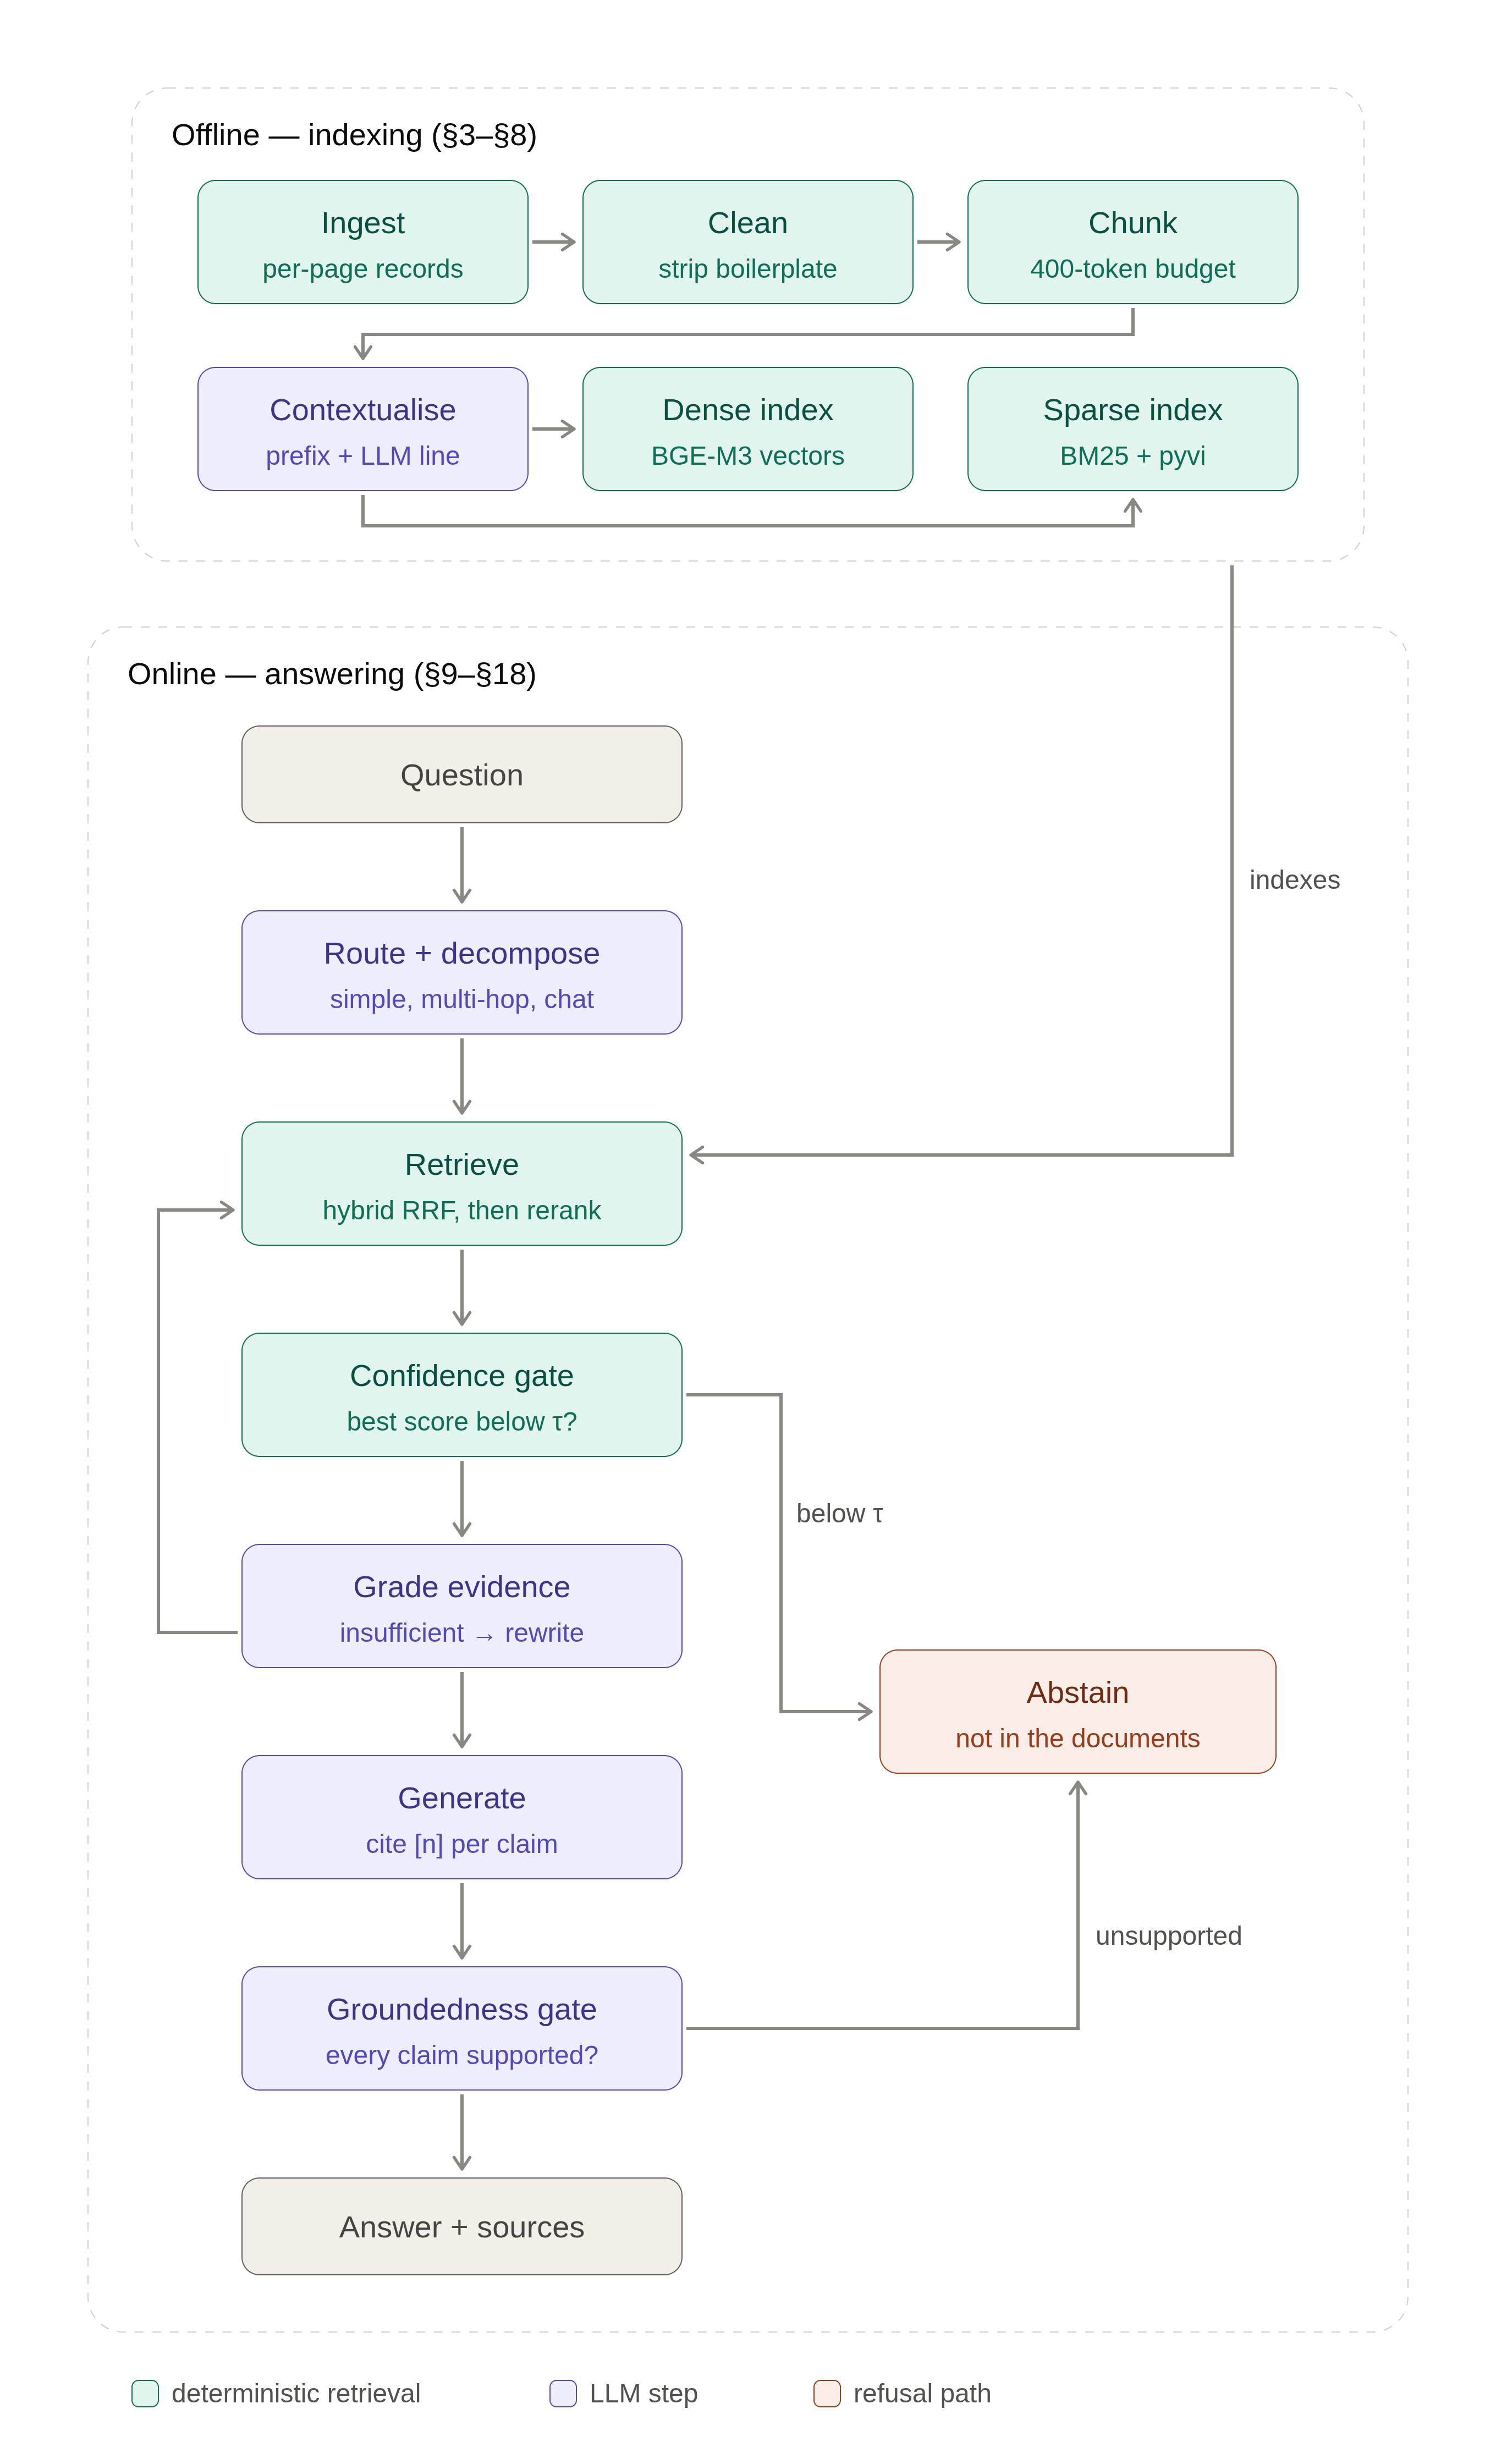

## Environment

Kaggle, single T4 or P100, internet enabled. Peak GPU memory approximately 9 GB.
End-to-end runtime approximately 45–70 minutes depending on corpus size and whether
LLM contextualisation is enabled.

---
# §1 Environment and configuration

All experimental parameters are declared in one cell so that a run is fully described by its
configuration. Seeds are fixed; generation is greedy throughout, so retrieval results and
metric values are reproducible across runs of the same configuration.

In [1]:
!pip install -q pymupdf rank_bm25 pyvi bitsandbytes accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.7/25.7 MB 60.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 89.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 MB 49.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 66.3 MB/s eta 0:00:00


In [2]:
import os, re, gc, json, time, pickle, random, warnings
from dataclasses import dataclass, field, asdict
from collections import Counter, defaultdict
from typing import List, Dict, Tuple, Callable, Optional, Any

import numpy as np
import pandas as pd
import torch
import matplotlib
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Turing-class GPUs (Kaggle T4) have no native bfloat16; requesting it silently selects a
# slow emulated path. Detect rather than hardcode.
COMPUTE_DTYPE = (torch.bfloat16 if DEVICE == "cuda" and torch.cuda.is_bf16_supported()
                 else torch.float16)

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 10, "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False, "figure.facecolor": "white",
})
PALETTE = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3", "#937860"]

print("device       :", DEVICE)
if DEVICE == "cuda":
    print("gpu          :", torch.cuda.get_device_name(0),
          f"({torch.cuda.get_device_properties(0).total_memory/1e9:.0f} GB)")
print("compute dtype:", COMPUTE_DTYPE)
print("torch        :", torch.__version__)

device       : cuda
gpu          : Tesla T4 (16 GB)
compute dtype: torch.bfloat16
torch        : 2.10.0+cu128


In [3]:
# ==========================  EXPERIMENT CONFIGURATION  ==========================

# ---- corpus ----
DATA_FILES = [
    "/kaggle/input/datasets/devkcng/datarag/data/quyche/quy-che-hoc-tap.pdf",
    "/kaggle/input/datasets/devkcng/datarag/data/giaotrinh/giao-trinh-co-so-du-lieu-ngo-tran-thanh-thao-csdl.pdf",
    "/kaggle/input/datasets/devkcng/pdfdata/cam-nang-chuyen-doi-so.pdf",
    "/kaggle/input/datasets/devkcng/pdfdata/cloudsplit.pdf",
    
]
AUTO_DISCOVER = True          # fall back to scanning /kaggle/input if the paths above miss

WORK_DIR  = "/kaggle/working"
INDEX_DIR = os.path.join(WORK_DIR, "index")
FIG_DIR   = os.path.join(WORK_DIR, "figures")
for d in (INDEX_DIR, FIG_DIR):
    os.makedirs(d, exist_ok=True)

# ---- models ----
EMBEDDING_MODEL  = "BAAI/bge-m3"              # multilingual dense encoder, 8192 ctx
BASELINE_MODEL   = "thenlper/gte-small"       # monolingual control for RQ1
RERANKER_MODEL   = "BAAI/bge-reranker-v2-m3"  # multilingual cross-encoder
READER_MODEL     = "Qwen/Qwen2.5-7B-Instruct" # -> Qwen2.5-3B-Instruct if memory is tight

# ---- chunking ----
CHUNK_TOKENS  = 400           # measured with the encoder's tokenizer, not characters
CHUNK_OVERLAP = 60
MIN_CHUNK_CHARS = 25

# ---- contextualisation (RQ4) ----
USE_LLM_CONTEXT     = True    # LLM writes a situating sentence per chunk before embedding
MAX_CONTEXT_CHUNKS  = 900     # auto-disables above this, to bound indexing time
CONTEXT_BATCH       = 8

# ---- retrieval ----
CANDIDATES_K = 30             # first-stage candidates handed to the reranker
FINAL_K      = 5              # passages that reach the reader
RRF_K        = 60             # Reciprocal Rank Fusion smoothing constant

# ---- agentic loop ----
MAX_RETRIEVAL_ROUNDS = 2      # one rewrite-and-retry after the initial attempt
MAX_SUBQUERIES       = 3

# ---- evaluation ----
N_EVAL_QUESTIONS = 36         # synthetic in-domain questions
RAGAS_SAMPLES    = 12         # end-to-end generations scored by RAGAS (slow: ~8 LLM calls each)
CALIBRATION_SPLIT = 0.5       # fraction of in-domain / OOD questions used to fit the threshold

pd.set_option("display.width", 140)
print("configuration loaded")

configuration loaded


---
# §2 Models

Three models are loaded once and shared by every stage.

**Reader** — `Qwen2.5-7B-Instruct`, quantised to 4-bit NF4 with double quantisation. Beyond
answer generation, the reader is used as a *component* in several pipeline stages: it writes
chunk contexts (§6), generates the evaluation set (§12), routes and decomposes queries (§15),
grades retrieved evidence (§18), and acts as the judge for faithfulness metrics (§19). Using
one local model for all of these keeps the notebook self-contained and free of API keys, at
the cost of the judge sharing the generator's blind spots — a limitation revisited in §22.

**Encoder** — `BGE-M3`. Multilingual and cross-lingual, so a Vietnamese question can retrieve
English evidence and vice versa. Unlike the `bge-*-en-v1.5` family it requires no query
instruction prefix.

**Reranker** — `bge-reranker-v2-m3`, a cross-encoder from the same family. It scores a
`(query, passage)` pair jointly rather than comparing two independently computed vectors,
which is both more accurate and — critically for §14 — produces a score with enough dynamic
range to threshold on.

Generation is greedy (`do_sample=False`). For a grounded system, reproducibility is worth more
than diversity, and non-deterministic decoding would make the metrics below unrepeatable.

In [4]:
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=COMPUTE_DTYPE,
)

reader_tok = AutoTokenizer.from_pretrained(READER_MODEL)
if reader_tok.pad_token is None:
    reader_tok.pad_token = reader_tok.eos_token

reader = AutoModelForCausalLM.from_pretrained(
    READER_MODEL, quantization_config=bnb_config, device_map="auto",
)
reader.eval()
def gpu_gb() -> float:
    return torch.cuda.memory_allocated() / 1e9 if DEVICE == "cuda" else 0.0


print(f"reader: {READER_MODEL} | {gpu_gb():.2f} GB allocated")

config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

reader: Qwen/Qwen2.5-7B-Instruct | 1.45 GB allocated


In [5]:
LLM_CALLS = Counter()          # instrumentation: how many generations each stage costs


@torch.inference_mode()
def llm_chat(messages: List[dict], max_new_tokens: int = 512,
             temperature: float = 0.0, tag: str = "misc") -> str:
    '''Single greedy chat completion from the local reader.'''
    LLM_CALLS[tag] += 1
    prompt = reader_tok.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    enc = reader_tok([prompt], return_tensors="pt", truncation=True, max_length=8192).to(reader.device)
    kw = dict(max_new_tokens=max_new_tokens, pad_token_id=reader_tok.pad_token_id)
    kw.update(dict(do_sample=True, temperature=temperature, top_p=0.9)
              if temperature > 0 else dict(do_sample=False))
    out = reader.generate(**enc, **kw)
    return reader_tok.decode(out[0][enc.input_ids.shape[1]:], skip_special_tokens=True).strip()


@torch.inference_mode()
def llm_batch(batch: List[List[dict]], max_new_tokens: int = 64,
              tag: str = "batch") -> List[str]:
    '''Batched greedy completion. Left padding is required for decoder-only generation.'''
    LLM_CALLS[tag] += len(batch)
    prompts = [reader_tok.apply_chat_template(m, tokenize=False, add_generation_prompt=True)
               for m in batch]
    old_side, reader_tok.padding_side = reader_tok.padding_side, "left"
    enc = reader_tok(prompts, return_tensors="pt", padding=True,
                     truncation=True, max_length=3072).to(reader.device)
    out = reader.generate(**enc, max_new_tokens=max_new_tokens, do_sample=False,
                          pad_token_id=reader_tok.pad_token_id)
    reader_tok.padding_side = old_side
    gen = out[:, enc.input_ids.shape[1]:]
    return [reader_tok.decode(g, skip_special_tokens=True).strip() for g in gen]


def yes_no(question: str, system: str = "Answer with exactly one word: YES or NO.",
           tag: str = "judge") -> Optional[bool]:
    '''Binary LLM judgement used by the graders and metrics. None means unparseable.'''
    v = llm_chat([{"role": "system", "content": system},
                  {"role": "user", "content": question}], max_new_tokens=5, tag=tag).upper()
    if "YES" in v:
        return True
    if "NO" in v:
        return False
    return None


print(llm_chat([{"role": "user", "content": "Reply with one short sentence in Vietnamese."}],
               max_new_tokens=40, tag="smoke"))

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Bạn muốn biết điều gì trong tiếng Việt?


In [6]:
from sentence_transformers import SentenceTransformer, CrossEncoder

embedder = SentenceTransformer(EMBEDDING_MODEL, device=DEVICE)
if DEVICE == "cuda":
    embedder = embedder.half()
emb_tok = AutoTokenizer.from_pretrained(EMBEDDING_MODEL)

# The dtype keyword was renamed across sentence-transformers releases; degrade gracefully.
try:
    reranker = CrossEncoder(RERANKER_MODEL, max_length=512, device=DEVICE,
                            model_kwargs={"torch_dtype": COMPUTE_DTYPE})
except TypeError:
    try:
        reranker = CrossEncoder(RERANKER_MODEL, max_length=512, device=DEVICE,
                                automodel_args={"torch_dtype": COMPUTE_DTYPE})
    except TypeError:
        reranker = CrossEncoder(RERANKER_MODEL, max_length=512, device=DEVICE)


def rerank_scores(pairs: List[Tuple[str, str]], batch_size: int = 16) -> np.ndarray:
    '''Cross-encoder relevance in [0, 1]. Some versions return logits; normalise either way.'''
    if not pairs:
        return np.zeros(0, dtype=np.float32)
    s = np.asarray(reranker.predict(pairs, batch_size=batch_size, show_progress_bar=False),
                   dtype=np.float32).reshape(-1)
    if s.min() < 0.0 or s.max() > 1.0:
        s = 1.0 / (1.0 + np.exp(-s))
    return s


print(f"encoder : {EMBEDDING_MODEL} | dim {embedder.get_sentence_embedding_dimension()}")
print(f"reranker: {RERANKER_MODEL}")
print(f"gpu     : {gpu_gb():.2f} GB allocated")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/54.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/687 [00:00<?, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

encoder : BAAI/bge-m3 | dim 1024
reranker: BAAI/bge-reranker-v2-m3
gpu     : 3.74 GB allocated


---
# §3 Ingestion — provenance is established here or never

A retrieved passage is only useful if the system can say where it came from. Provenance
cannot be reconstructed after the fact, so it is attached at load time: **one record per
page**, carrying the source filename and page number, and every downstream structure inherits
those fields. Concatenating a document into a single string before chunking — the most common
shortcut in RAG tutorials — irreversibly destroys this, and with it any possibility of real
citations.

The loader also verifies that extraction actually produced text. A PDF of scanned images
returns pages with near-zero characters; discovering that here rather than after building an
index saves a great deal of confusion.

In [7]:
import fitz  # PyMuPDF


@dataclass
class Page:
    source: str
    page: int
    text: str


def load_pdf_pages(path: str) -> List[Page]:
    doc = fitz.open(path)
    name = os.path.basename(path)
    pages = [Page(name, i + 1, p.get_text("text")) for i, p in enumerate(doc)]
    doc.close()
    return pages


def load_any(path: str) -> List[Page]:
    ext = os.path.splitext(path)[1].lower()
    name = os.path.basename(path)
    if ext == ".pdf":
        return load_pdf_pages(path)
    if ext in (".txt", ".md"):
        with open(path, encoding="utf-8", errors="ignore") as f:
            return [Page(name, 1, f.read())]
    if ext in (".doc", ".docx"):
        from docx import Document as DocxDocument
        return [Page(name, 1, "\n".join(p.text for p in DocxDocument(path).paragraphs))]
    if ext == ".csv":
        return [Page(name, 1, pd.read_csv(path).to_string(index=False))]
    raise ValueError(f"unsupported file type: {ext}")


def resolve_inputs(paths: List[str]) -> List[str]:
    present = [p for p in paths if os.path.exists(p)]
    if present:
        return present
    if not AUTO_DISCOVER:
        raise FileNotFoundError(f"none of the configured paths exist: {paths}")
    found = []
    for root, _, files in os.walk("/kaggle/input"):
        for fn in files:
            if os.path.splitext(fn)[1].lower() in (".pdf", ".txt", ".md", ".docx", ".doc", ".csv"):
                found.append(os.path.join(root, fn))
    if not found:
        raise FileNotFoundError(
            "/kaggle/input contains no loadable documents. Attach the dataset via "
            "'+ Add Input' in the notebook sidebar, then re-run this cell."
        )
    print("configured paths missing; auto-discovered instead:")
    for f in sorted(found):
        print("   ", f)
    return sorted(found)


DATA_FILES = resolve_inputs(DATA_FILES)

PAGES: List[Page] = []
rows = []
for fp in DATA_FILES:
    try:
        loaded = load_any(fp)
        chars = sum(len(p.text) for p in loaded)
        PAGES.extend(loaded)
        rows.append({"document": os.path.basename(fp), "pages": len(loaded), "chars": chars,
                     "chars/page": round(chars / max(len(loaded), 1))})
    except Exception as e:
        print(f"FAILED {fp}: {type(e).__name__}: {e}")

corpus_stats = pd.DataFrame(rows)
display(corpus_stats)

if not PAGES:
    raise RuntimeError("ingestion produced 0 pages — see the FAILED lines above")
for r in rows:
    if r["chars/page"] < 100:
        print(f"WARNING: {r['document']} yields {r['chars/page']} chars/page. "
              "This is likely a scanned PDF with no text layer and would require OCR.")

print(f"\ncorpus: {len(PAGES)} pages, {sum(len(p.text) for p in PAGES):,} characters")

,document,pages,chars,chars/page
0,quy-che-hoc-tap.pdf,14,32881,2349
1,giao-trinh-co-so-du-lieu-ngo-tran-thanh-thao-c...,177,237230,1340
2,cam-nang-chuyen-doi-so.pdf,85,182982,2153
3,cloudsplit.pdf,372,814253,2189



corpus: 648 pages, 1,267,346 characters


---
# §4 Normalisation — removing what repeats

Running headers, footers and page numbers appear on nearly every page. Once embedded they
become passages that are weakly similar to *every* query, and they crowd out real content in
the candidate list. They are identified structurally rather than by pattern matching: a line
that occurs in the header or footer zone of a large fraction of a document's pages is
boilerplate by definition.

The step is guarded. If cleaning removes more than half the corpus the heuristic has
misfired — a real risk on short documents where body text can repeat — and the original text
is kept instead. A preprocessing step that can silently delete the corpus is worse than no
preprocessing step.

In [8]:
def strip_boilerplate(pages: List[Page], zone: int = 2, threshold: float = 0.6) -> List[Page]:
    by_source: Dict[str, List[Page]] = defaultdict(list)
    for p in pages:
        by_source[p.source].append(p)

    cleaned, report = [], []
    for source, group in by_source.items():
        counter = Counter()
        for p in group:
            lines = [l.strip() for l in p.text.split("\n") if l.strip()]
            zone_lines = set(lines[:zone]) | set(lines[-zone:])
            for l in zone_lines:
                if len(l) < 120:
                    counter[l] += 1
        cutoff = max(3, int(threshold * len(group)))
        boiler = {l for l, c in counter.items() if c >= cutoff}
        report.append({"document": source, "pages": len(group),
                       "boilerplate_lines": len(boiler),
                       "example": (sorted(boiler, key=len, reverse=True)[:1] or [""])[0][:60]})
        for p in group:
            text = "\n".join(l for l in p.text.split("\n") if l.strip() not in boiler)
            text = re.sub(r"[ \t]+", " ", text)
            text = re.sub(r"\n{3,}", "\n\n", text).strip()
            if text:
                cleaned.append(Page(p.source, p.page, text))
    cleaned.sort(key=lambda p: (p.source, p.page))
    display(pd.DataFrame(report))
    return cleaned


raw_chars = sum(len(p.text) for p in PAGES)
candidate = strip_boilerplate(PAGES)
kept_chars = sum(len(p.text) for p in candidate)

if not candidate or kept_chars < 0.5 * raw_chars:
    print(f"\nSAFETY: cleaning removed {100*(1-kept_chars/max(raw_chars,1)):.0f}% of the text "
          "— heuristic rejected, keeping the raw pages.")
else:
    PAGES = candidate
    print(f"\n{len(PAGES)} pages retained | {raw_chars:,} -> {kept_chars:,} chars "
          f"({100*(1-kept_chars/raw_chars):.1f}% removed)")

,document,pages,boilerplate_lines,example
0,quy-che-hoc-tap.pdf,14,0,
1,giao-trinh-co-so-du-lieu-ngo-tran-thanh-thao-c...,177,2,messages.downloaded_by
2,cam-nang-chuyen-doi-so.pdf,85,1,CẨM NANG CHUYỂN ĐỔI SỐ
3,cloudsplit.pdf,372,0,



639 pages retained | 1,267,346 -> 1,256,217 chars (0.9% removed)


---
# §5 Chunking

Chunk size is a bias–variance tradeoff. Passages that are too small lose the context needed to
interpret them; passages that are too large dilute the embedding across several topics and
waste the reader's attention budget. The budget here is **measured in encoder tokens, not
characters** — a 1000-character chunk is roughly 250 tokens of English but can exceed 500
tokens of Vietnamese, so a character budget silently truncates one language and not the other.

Splitting is hierarchical and respects document structure: paragraph boundaries first,
sentence boundaries for oversized paragraphs, hard token cuts only as a last resort. A
`CHUNK_OVERLAP`-token tail carries forward so that a fact spanning a boundary survives in at
least one chunk.

In [9]:
@dataclass
class Chunk:
    id: int
    text: str              # what the reader sees — no synthetic additions
    prefix: str            # deterministic structural context
    source: str
    page: int
    heading: str = ""
    llm_context: str = ""  # filled in §6 when USE_LLM_CONTEXT is on

    def embed_text(self, mode: str = "structural") -> str:
        if mode == "llm" and self.llm_context:
            return f"{self.prefix} {self.llm_context}\n{self.text}"
        if mode == "raw":
            return self.text
        return f"{self.prefix}\n{self.text}"


HEADING_RE = re.compile(
    r"^\s*(?:(?:CHAPTER|CHƯƠNG|PHẦN|PART|MỤC|SECTION)\b.*"
    r"|[IVXLC]+[\.\)]\s+\S.*"
    r"|\d+(?:\.\d+)*[\.\)]?\s+\S.*"
    r"|#{1,6}\s+\S.*)$", re.IGNORECASE)


def ntokens(text: str) -> int:
    return len(emb_tok.encode(text, add_special_tokens=False))


def split_blocks(text: str) -> List[str]:
    '''Paragraphs, then sentences, then hard token cuts.'''
    paras = [p.strip() for p in re.split(r"\n\s*\n", text) if p.strip()]
    if len(paras) <= 1 and text.count("\n") > 3:
        paras = [p.strip() for p in text.split("\n") if p.strip()]

    blocks: List[str] = []
    for para in paras:
        if ntokens(para) <= CHUNK_TOKENS:
            blocks.append(para)
            continue
        buf = ""
        for s in re.split(r"(?<=[.!?;:])\s+|\n", para):
            s = s.strip()
            if not s:
                continue
            if ntokens(s) > CHUNK_TOKENS:
                if buf:
                    blocks.append(buf); buf = ""
                ids = emb_tok.encode(s, add_special_tokens=False)
                for i in range(0, len(ids), CHUNK_TOKENS):
                    blocks.append(emb_tok.decode(ids[i:i + CHUNK_TOKENS]))
                continue
            cand = f"{buf} {s}".strip()
            if ntokens(cand) > CHUNK_TOKENS:
                blocks.append(buf); buf = s
            else:
                buf = cand
        if buf:
            blocks.append(buf)
    return blocks


def chunk_pages(pages: List[Page]) -> List[Chunk]:
    chunks: List[Chunk] = []
    seen, next_id = set(), 0
    heading_by_source: Dict[str, str] = {}
    empty = []

    for p in pages:
        for line in p.text.split("\n")[:12]:
            if HEADING_RE.match(line) and len(line.strip()) < 100:
                heading_by_source[p.source] = line.strip()
                break
        heading = heading_by_source.get(p.source, "")
        title = os.path.splitext(p.source)[0].replace("-", " ").replace("_", " ")
        prefix = f"[{title} | page {p.page}" + (f" | {heading}" if heading else "") + "]"

        def flush(parts):
            nonlocal next_id
            body = "\n\n".join(parts).strip()
            if len(body) < MIN_CHUNK_CHARS:
                return
            key = (p.source, body)
            if key in seen:
                return
            seen.add(key)
            chunks.append(Chunk(id=next_id, text=body, prefix=prefix,
                                source=p.source, page=p.page, heading=heading))
            next_id += 1

        blocks = split_blocks(p.text)
        if not blocks:
            empty.append((p.source, p.page)); continue

        buf, buf_tok = [], 0
        for b in blocks:
            bt = ntokens(b)
            if buf and buf_tok + bt > CHUNK_TOKENS:
                flush(buf)
                pending, tail = [], 0
                for prev in reversed(buf[1:] if len(buf) > 1 else []):
                    t = ntokens(prev)
                    if tail + t > CHUNK_OVERLAP:
                        break
                    pending.insert(0, prev); tail += t
                buf, buf_tok = pending, tail
            buf.append(b); buf_tok += bt
        if buf:
            flush(buf)

    if empty:
        print(f"note: {len(empty)} page(s) produced no text, e.g. {empty[:3]}")
    return chunks


CHUNKS = chunk_pages(PAGES)
if not CHUNKS:
    raise RuntimeError(f"0 chunks from {len(PAGES)} pages — inspect repr(PAGES[0].text[:800])")

CHUNK_LENS = np.array([ntokens(c.text) for c in CHUNKS])
print(f"chunks: {len(CHUNKS)}")
print(f"tokens/chunk: mean {CHUNK_LENS.mean():.0f} | median {np.median(CHUNK_LENS):.0f} | "
      f"min {CHUNK_LENS.min()} | max {CHUNK_LENS.max()}")
print("\n--- example ---")
print(CHUNKS[len(CHUNKS) // 2].embed_text()[:500])

chunks: 1116
tokens/chunk: mean 294 | median 332 | min 7 | max 450

--- example ---
[cloudsplit | page 237 | 9.5  Summary]
• Cloud-aware software development requires multitenant, highly scal­ able architecture (see Section 9.4). Review Questions

1. What is Software as a Service (SaaS)? How is it different from tradi­
tional software?

2. Briefly explain the benefits of the SaaS application.

3. Is it wise to choose the SaaS delivery model for all kinds of applica­
tions? Justify your answer.


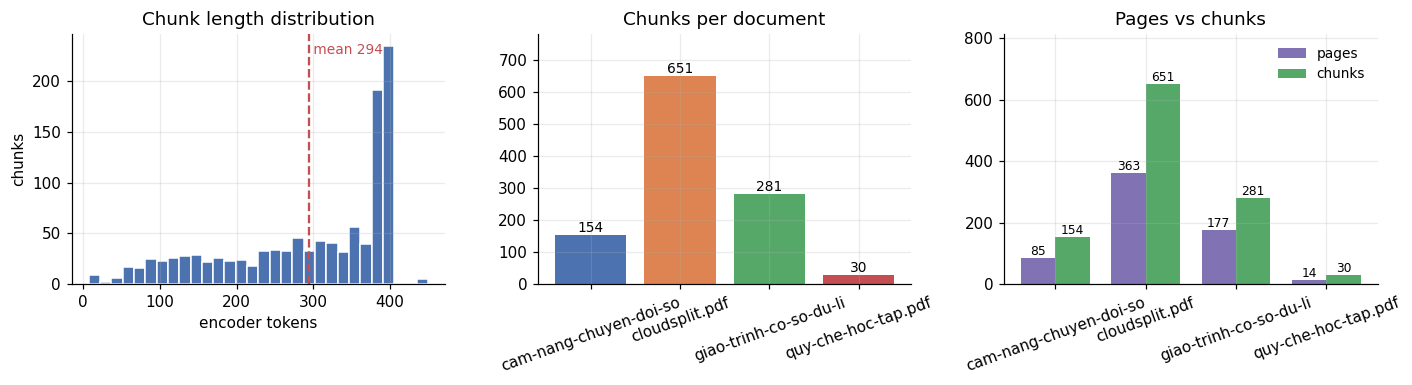

In [10]:
# ---- Figure 1: corpus and chunk statistics ----
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))

axes[0].hist(CHUNK_LENS, bins=30, color=PALETTE[0], edgecolor="white")
axes[0].axvline(CHUNK_LENS.mean(), color=PALETTE[3], ls="--", lw=1.5)
axes[0].text(CHUNK_LENS.mean(), axes[0].get_ylim()[1]*0.92, f" mean {CHUNK_LENS.mean():.0f}",
             color=PALETTE[3], fontsize=9)
axes[0].set_title("Chunk length distribution"); axes[0].set_xlabel("encoder tokens")
axes[0].set_ylabel("chunks")

src_counts = Counter(c.source for c in CHUNKS)
names = [s[:22] for s in src_counts]
b = axes[1].bar(names, list(src_counts.values()), color=PALETTE[:len(src_counts)])
axes[1].bar_label(b, fmt="%d", fontsize=9)
axes[1].set_title("Chunks per document"); axes[1].tick_params(axis="x", rotation=20)
axes[1].set_ylim(0, max(src_counts.values()) * 1.2)

pages_per_src = Counter(p.source for p in PAGES)
x = np.arange(len(src_counts))
w = 0.38
b1 = axes[2].bar(x - w/2, [pages_per_src[s] for s in src_counts], w, label="pages", color=PALETTE[4])
b2 = axes[2].bar(x + w/2, [src_counts[s] for s in src_counts], w, label="chunks", color=PALETTE[2])
axes[2].bar_label(b1, fmt="%d", fontsize=8); axes[2].bar_label(b2, fmt="%d", fontsize=8)
axes[2].set_xticks(x); axes[2].set_xticklabels(names, rotation=20)
axes[2].set_title("Pages vs chunks"); axes[2].legend(frameon=False, fontsize=9)
axes[2].set_ylim(0, max(list(src_counts.values()) + list(pages_per_src.values())) * 1.25)

plt.tight_layout(); plt.savefig(f"{FIG_DIR}/fig1_corpus.png", bbox_inches="tight"); plt.show()

---
# §6 Contextualisation — what the encoder sees is not what the reader sees

A chunk taken out of its document is frequently uninterpretable in isolation. *"This applies
only to the second category"* or a bare table row carries almost no retrievable signal, even
though it may hold the answer. The remedy is to embed a *contextualised* form of the chunk
while showing the reader the original text, so that citations stay clean.

Two variants are built and compared in §13:

**Structural (deterministic, free).** Prepend document title, page number and nearest heading.
Costs nothing and always applies.

**LLM-written (RQ4).** The reader is shown the chunk together with a window of the surrounding
document and asked to write one situating sentence — what this passage is about and where it
sits. This is *contextual retrieval*; it typically produces the largest single recall gain
available for the cost, but it requires one generation per chunk at indexing time. Generation
is batched and capped by `MAX_CONTEXT_CHUNKS`.

In [11]:
CTX_PROMPT = (
    "Below is a document excerpt and one passage taken from it.\n"
    "Write ONE short sentence (max 25 words) situating the passage: what it is about and "
    "where it belongs in the document. Do not summarise the content in detail. "
    "Write in the same language as the passage. Return only the sentence.\n\n"
    "<document>\n{doc}\n</document>\n\n<passage>\n{chunk}\n</passage>"
)

# Rebuild a light document window per source so each chunk sees its neighbourhood.
DOC_TEXT = defaultdict(str)
for p in PAGES:
    DOC_TEXT[p.source] += p.text + "\n"


def contextualise(chunks: List[Chunk], window: int = 2500, batch: int = CONTEXT_BATCH):
    t0 = time.time()
    for i in range(0, len(chunks), batch):
        group = chunks[i:i + batch]
        msgs = []
        for c in group:
            doc = DOC_TEXT[c.source]
            centre = doc.find(c.text[:80])
            lo = max(0, (centre if centre >= 0 else 0) - window // 2)
            msgs.append([{"role": "user", "content": CTX_PROMPT.format(
                doc=doc[lo:lo + window], chunk=c.text[:1500])}])
        for c, out in zip(group, llm_batch(msgs, max_new_tokens=48, tag="contextualise")):
            c.llm_context = out.split("\n")[0].strip().strip('"')[:250]
        if i % (batch * 10) == 0:
            done = min(i + batch, len(chunks))
            rate = (time.time() - t0) / max(done, 1)
            print(f"  {done}/{len(chunks)}  eta {rate*(len(chunks)-done)/60:.1f} min", flush=True)
    print(f"contextualised {len(chunks)} chunks in {(time.time()-t0)/60:.1f} min")


if USE_LLM_CONTEXT and len(CHUNKS) > MAX_CONTEXT_CHUNKS:
    print(f"{len(CHUNKS)} chunks exceeds MAX_CONTEXT_CHUNKS={MAX_CONTEXT_CHUNKS}; "
          "LLM contextualisation disabled to bound runtime. RQ4 will be skipped.")
    USE_LLM_CONTEXT = False

if USE_LLM_CONTEXT:
    contextualise(CHUNKS)
    ex = next((c for c in CHUNKS if c.llm_context), None)
    if ex:
        print("\n--- example ---")
        print("structural:", ex.prefix)
        print("llm-written:", ex.llm_context)
else:
    print("using structural contextualisation only")

1116 chunks exceeds MAX_CONTEXT_CHUNKS=900; LLM contextualisation disabled to bound runtime. RQ4 will be skipped.
using structural contextualisation only


---
# §7 Dense index

Chunks are encoded into a normalised vector space; retrieval is exact inner-product search
over the resulting matrix. At this corpus size an approximate index (HNSW, IVF) would add
recall loss and tuning burden without a latency benefit, so exact search is the correct
choice. The class below takes a *mode* so that the same code produces the structural index,
the LLM-contextualised index and the monolingual control, holding everything else constant —
which is what makes §13 a controlled comparison rather than a collection of anecdotes.

In [12]:
class DenseIndex:
    def __init__(self, model, chunks: List[Chunk], mode: str = "structural",
                 batch_size: int = 16, name: str = ""):
        self.model, self.chunks, self.mode = model, chunks, mode
        self.name = name or mode
        t0 = time.time()
        self.emb = model.encode(
            [c.embed_text(mode) for c in chunks],
            batch_size=batch_size, normalize_embeddings=True,
            show_progress_bar=True, convert_to_numpy=True,
        ).astype(np.float32)
        self.build_seconds = time.time() - t0

    def search(self, query: str, k: int = 30) -> List[Tuple[int, float]]:
        q = self.model.encode([query], normalize_embeddings=True,
                              convert_to_numpy=True)[0].astype(np.float32)
        scores = self.emb @ q
        k = min(k, len(scores))
        top = np.argpartition(-scores, k - 1)[:k]
        top = top[np.argsort(-scores[top])]
        return [(int(i), float(scores[i])) for i in top]


dense_struct = DenseIndex(embedder, CHUNKS, mode="structural", name="bge-m3 structural")
print(f"{dense_struct.name}: {dense_struct.emb.shape} in {dense_struct.build_seconds:.0f}s")

dense_ctx = None
if USE_LLM_CONTEXT:
    dense_ctx = DenseIndex(embedder, CHUNKS, mode="llm", name="bge-m3 llm-context")
    print(f"{dense_ctx.name}: {dense_ctx.emb.shape} in {dense_ctx.build_seconds:.0f}s")

Batches:   0%|          | 0/70 [00:00<?, ?it/s]

bge-m3 structural: (1116, 1024) in 16s


---
# §8 Sparse index — BM25, and why segmentation is not optional

Dense retrieval fails predictably on rare surface forms: product codes, acronyms, proper
nouns, anything whose meaning is its exact string. BM25 covers precisely that failure mode,
which is why the two are complementary rather than redundant.

Applying BM25 to Vietnamese naively does not work. Vietnamese orthography separates
*syllables*, not words: **chuyển đổi số** ("digital transformation") is three whitespace
tokens but one lexical unit, and a whitespace tokeniser therefore matches the fragment *số*
against every occurrence of the word "number" in the corpus. `pyvi` performs word
segmentation first, joining syllables into compounds. Segmentation is applied only to text
detected as Vietnamese, so English passages are unaffected.

Language is detected by diacritic density rather than a statistical detector. Detectors such
as `langdetect` are trained on documents and are unreliable on the five-to-ten-word strings
that queries actually consist of; diacritic density is nearly perfect for this specific
binary decision.

In [13]:
from rank_bm25 import BM25Okapi

try:
    from pyvi import ViTokenizer
    HAS_PYVI = True
except Exception as e:
    print("pyvi unavailable; falling back to whitespace tokenisation:", e)
    HAS_PYVI = False

VN_CHARS = re.compile(r"[ăâđêôơưàáảãạằắẳẵặầấẩẫậèéẻẽẹềếểễệìíỉĩị"
                      r"òóỏõọồốổỗộờớởỡợùúủũụừứửữựỳýỷỹỵ]")


def is_vietnamese(text: str) -> bool:
    low = text.lower()
    return bool(VN_CHARS.search(low)) and len(VN_CHARS.findall(low)) / max(len(low), 1) > 0.01


def tokenize_for_bm25(text: str, segment: bool = True) -> List[str]:
    text = text.lower()
    if segment and HAS_PYVI and is_vietnamese(text):
        text = ViTokenizer.tokenize(text)
    text = re.sub(r"[^\w\s_]", " ", text, flags=re.UNICODE)
    return [t for t in text.split() if len(t) > 1]


class SparseIndex:
    def __init__(self, chunks: List[Chunk], segment: bool = True, name: str = "bm25"):
        self.chunks, self.segment, self.name = chunks, segment, name
        self.bm25 = BM25Okapi([tokenize_for_bm25(c.embed_text(), segment) for c in chunks])

    def search(self, query: str, k: int = 30) -> List[Tuple[int, float]]:
        scores = self.bm25.get_scores(tokenize_for_bm25(query, self.segment))
        top = np.argsort(-scores)[:k]
        return [(int(i), float(scores[i])) for i in top if scores[i] > 0]


sparse         = SparseIndex(CHUNKS, segment=True,  name="bm25 + pyvi")
sparse_nosegm  = SparseIndex(CHUNKS, segment=False, name="bm25 whitespace")   # control for RQ2

demo = "Chuyển đổi số quốc gia là gì?"
print("pyvi available :", HAS_PYVI)
print("segmented      :", tokenize_for_bm25(demo, True))
print("unsegmented    :", tokenize_for_bm25(demo, False))

pyvi available : True
segmented      : ['chuyển_đổi', 'số', 'quốc_gia', 'là', 'gì']
unsegmented    : ['chuyển', 'đổi', 'số', 'quốc', 'gia', 'là', 'gì']


---
# §9 Fusion — Reciprocal Rank Fusion

Dense cosine similarity lives on a bounded scale with a compressed high end; BM25 scores are
unbounded and corpus-dependent. Combining them by weighted sum therefore requires
normalisation, and any normalisation scheme introduces a hyperparameter that must be tuned per
corpus.

RRF sidesteps this entirely by discarding the scores and fusing on *rank*:

$$\text{RRF}(d) = \sum_{r \in \text{retrievers}} \frac{1}{k + \text{rank}_r(d)}$$

with $k = 60$ conventionally. A document ranked highly by either retriever surfaces; one
ranked highly by both surfaces further. There is nothing to tune and nothing to re-tune when
the corpus changes, which is why it has become the default fusion method.

In [14]:
def rrf_fuse(*rankings, k: int = RRF_K, top_n: int = CANDIDATES_K) -> List[int]:
    scores: Dict[int, float] = defaultdict(float)
    for ranking in rankings:
        for rank, (idx, _) in enumerate(ranking):
            scores[idx] += 1.0 / (k + rank + 1)
    return [i for i, _ in sorted(scores.items(), key=lambda kv: -kv[1])][:top_n]


class Retriever:
    '''First-stage candidate generation. Either half can be disabled for ablation.'''

    def __init__(self, dense: Optional[DenseIndex] = None,
                 sparse: Optional[SparseIndex] = None, name: str = ""):
        self.dense, self.sparse = dense, sparse
        self.name = name or " + ".join(x.name for x in (dense, sparse) if x)

    def candidates(self, query: str, n: int = CANDIDATES_K) -> List[int]:
        rankings = []
        if self.dense is not None:
            rankings.append(self.dense.search(query, n))
        if self.sparse is not None:
            rankings.append(self.sparse.search(query, n))
        if not rankings:
            return []
        if len(rankings) == 1:
            return [i for i, _ in rankings[0]][:n]
        return rrf_fuse(*rankings, top_n=n)


RETRIEVER = Retriever(dense_ctx or dense_struct, sparse, name="production")
print("production first stage:", RETRIEVER.name)

production first stage: production


---
# §10 Reranking

First-stage retrieval compares a query vector with a passage vector computed independently of
it. A cross-encoder instead reads the concatenated pair and produces a single relevance score,
so it can resolve negation, qualifiers and entity mismatches that vector similarity cannot.
It is far too expensive to run over a corpus, but perfectly affordable over 30 candidates.

Two consequences matter for the rest of this notebook. First, the accuracy gain is typically
the largest of any single component (§13). Second — and less often exploited — the score is
*calibrated enough to threshold on*, which is what makes the abstention mechanism in §14
possible. First-stage similarity scores are unsuitable for this: their absolute values are
corpus-relative and a nonsense query still returns a nearest neighbour with a respectable
cosine.

In [15]:
@dataclass
class Hit:
    chunk: Chunk
    score: float
    rank: int


def rerank(query: str, candidate_ids: List[int], top_k: int = FINAL_K) -> List[Hit]:
    if not candidate_ids:
        return []
    scores = rerank_scores([(query, CHUNKS[i].text) for i in candidate_ids])
    order = np.argsort(-scores)[:top_k]
    return [Hit(CHUNKS[candidate_ids[i]], float(scores[i]), r)
            for r, i in enumerate(order)]


def retrieve(query: str, top_k: int = FINAL_K, n_candidates: int = CANDIDATES_K,
             retriever: Optional[Retriever] = None) -> List[Hit]:
    r = retriever or RETRIEVER
    return rerank(query, r.candidates(query, n_candidates), top_k)


for q in ["Chuyển đổi số là gì?", "What is cloud computing?"]:
    print(f"\n=== {q}")
    for h in retrieve(q, top_k=3):
        snippet = h.chunk.text[:100].replace("\n", " ")
        print(f"  {h.score:.3f}  {h.chunk.source} p.{h.chunk.page}  {snippet}...")


=== Chuyển đổi số là gì?
  1.000  cam-nang-chuyen-doi-so.pdf p.11  01. Cẩm nang cơ bản  20  21  CHUYỂN ĐỔI SỐ LÀ GÌ?  Trên thế giới, chuyển đổi số bắt đầu được nhắc đế...
  1.000  cam-nang-chuyen-doi-so.pdf p.28  01. Cẩm nang cơ bản  54  55  CHUYỂN ĐỔI SỐ NHỮNG GÌ?  Chuyển đổi số là quá trình thay đổi tổng thể v...
  1.000  cam-nang-chuyen-doi-so.pdf p.30  Chuyển đổi số cũng vậy. Chuyển đổi số là câu chuyện của chính  mỗi cá nhân, tổ chức. Chuyển đổi số l...

=== What is cloud computing?
  1.000  cloudsplit.pdf p.300  300  Essentials of Cloud Computing  12.1  Introduction  Cloud computing is one of the most popular t...
  0.996  cloudsplit.pdf p.12  12  Essentials of Cloud Computing  (e.g., use of cloud application Dropbox) ensures that we will be ...
  0.996  cloudsplit.pdf p.32  32  Essentials of Cloud Computing  3.4  Network Connectivity in Cloud Computing  Cloud computing is ...


---
# §11 Retrieval interface

The stages above compose into a single entry point. `retrieve()` runs first-stage fusion,
reranks the candidates, and returns `Hit` records carrying the passage, its cross-encoder
score and its rank. The score is retained rather than discarded because §14 depends on it.

In [16]:
def retrieval_report(query: str, top_k: int = FINAL_K) -> pd.DataFrame:
    hits = retrieve(query, top_k=top_k)
    return pd.DataFrame([{"rank": h.rank, "score": round(h.score, 4),
                          "source": h.chunk.source, "page": h.chunk.page,
                          "preview": h.chunk.text[:80].replace("\n", " ")} for h in hits])


display(retrieval_report("Chuyển đổi số là gì?"))

,rank,score,source,page,preview
0,0,1.0000,cam-nang-chuyen-doi-so.pdf,11,01. Cẩm nang cơ bản 20 21 CHUYỂN ĐỔI SỐ LÀ ...
1,1,1.0000,cam-nang-chuyen-doi-so.pdf,28,01. Cẩm nang cơ bản 54 55 CHUYỂN ĐỔI SỐ NHỮ...
2,2,1.0000,cam-nang-chuyen-doi-so.pdf,30,Chuyển đổi số cũng vậy. Chuyển đổi số là câu c...
3,3,0.9961,cam-nang-chuyen-doi-so.pdf,22,01. Cẩm nang cơ bản 42 43 CHUYỂN ĐỔI SỐ VÌ ...
4,4,0.9961,cam-nang-chuyen-doi-so.pdf,21,Những hệ lụy đến từ môi trường số có thể kể ra...


---
# §12 Evaluation harness

Nothing above can be justified without measurement. Three question sets are constructed.

**Synthetic in-domain set.** A chunk is sampled, the reader is asked to write a question
answerable only from that chunk, and the chunk id is recorded as ground truth. This yields
labelled `(question → relevant passage)` pairs at zero annotation cost, stratified across
documents so neither language dominates. The known bias is that generated questions reuse the
source passage's vocabulary, which flatters lexical retrieval; comparisons between
configurations remain valid because the bias applies equally to all of them.

**Hand-written set.** A template is provided below. Human-paraphrased questions do not share
surface form with the passage and are a strictly harder, more realistic test. Fifteen to
twenty are enough to matter, and any serious write-up should report both.

**Out-of-domain set.** Questions whose answers are certainly absent from the corpus. These
carry no retrieval label — their label is *"this must not be answered"* — and they are the
basis of the abstention calibration in §14. Without them the system's refusal behaviour is
untestable, which is why most RAG evaluations never report it.

In [17]:
GEN_PROMPT = {
    "vi": "Dựa vào đoạn văn dưới đây, hãy viết MỘT câu hỏi mà chỉ có thể trả lời được từ chính "
          "đoạn văn này. Câu hỏi phải cụ thể, tự nhiên, và KHÔNG được chứa các cụm từ như "
          "'theo đoạn văn' hay 'trong tài liệu'. Chỉ trả về câu hỏi.\n\nĐoạn văn:\n{ctx}",
    "en": "Based on the passage below, write ONE question answerable only from this passage. "
          "It must be specific and natural, and must NOT contain phrases like 'according to "
          "the passage' or 'in the document'. Return only the question.\n\nPassage:\n{ctx}",
}


def build_synthetic_set(n: int = N_EVAL_QUESTIONS, min_tokens: int = 120) -> List[dict]:
    pool = [c for c in CHUNKS if ntokens(c.text) >= min_tokens] or CHUNKS
    by_src: Dict[str, List[Chunk]] = defaultdict(list)
    for c in pool:
        by_src[c.source].append(c)
    per_src = max(1, n // max(len(by_src), 1))

    sample = []
    for group in by_src.values():
        sample.extend(random.sample(group, min(per_src, len(group))))

    msgs, meta = [], []
    for c in sample:
        lang = "vi" if is_vietnamese(c.text) else "en"
        msgs.append([{"role": "user", "content": GEN_PROMPT[lang].format(ctx=c.text[:2500])}])
        meta.append((c, lang))

    dataset = []
    for i in range(0, len(msgs), 4):
        outs = llm_batch(msgs[i:i + 4], max_new_tokens=80, tag="golden_set")
        for (c, lang), q in zip(meta[i:i + 4], outs):
            q = q.strip().strip('"').split("\n")[0].strip()
            if len(q) < 12:
                continue
            dataset.append({"question": q, "chunk_id": c.id, "lang": lang,
                            "source": c.source, "page": c.page, "origin": "synthetic"})
    return dataset


SYNTHETIC = build_synthetic_set()
print(f"{len(SYNTHETIC)} synthetic questions "
      f"({sum(d['lang']=='vi' for d in SYNTHETIC)} vi / "
      f"{sum(d['lang']=='en' for d in SYNTHETIC)} en)\n")
for d in SYNTHETIC[:5]:
    print(f"  [{d['lang']}] {d['question'][:95]}  ->  {d['source']} p.{d['page']}")

36 synthetic questions (27 vi / 9 en)

  [vi] Tại sao công ty du lịch này quyết định thay đổi kích thước bàn ăn trong nhà ăn của mình?  ->  cam-nang-chuyen-doi-so.pdf p.21
  [vi] Chuyển đổi số trong lĩnh vực nào được trình bày chi tiết nhất trong đoạn văn này?  ->  cam-nang-chuyen-doi-so.pdf p.7
  [vi] Ứng dụng này giúp cải thiện điều gì ở người bệnh bị giảm khả năng vận động hoặc có vấn đề về sứ  ->  cam-nang-chuyen-doi-so.pdf p.43
  [vi] Kinh tế số giúp người dân bán hàng đến được với bao nhiêu người trong phạm vi toàn cầu?  ->  cam-nang-chuyen-doi-so.pdf p.39
  [vi] Nền tảng VnAlert sử dụng công nghệ nào để thu thập và phân tích hàng trăm nghìn thông tin được   ->  cam-nang-chuyen-doi-so.pdf p.37


In [18]:
# ---- Hand-written in-domain questions -------------------------------------------------
# Optional but strongly recommended. Read a few pages, write questions in your own words,
# and set chunk_id to the id of the chunk that answers it. Use find_chunk() to locate ids.

def find_chunk(substring: str, limit: int = 5):
    '''Locate candidate chunk ids by substring, to label hand-written questions.'''
    out = [(c.id, c.source, c.page, c.text[:90].replace("\n", " "))
           for c in CHUNKS if substring.lower() in c.text.lower()][:limit]
    return pd.DataFrame(out, columns=["chunk_id", "source", "page", "preview"])


HANDWRITTEN: List[dict] = [
    # {"question": "...", "chunk_id": 123, "lang": "vi"},
]

for d in HANDWRITTEN:
    d.setdefault("origin", "handwritten")
    d.setdefault("lang", "vi" if is_vietnamese(d["question"]) else "en")
    c = CHUNKS[d["chunk_id"]]
    d.setdefault("source", c.source); d.setdefault("page", c.page)

INDOMAIN = SYNTHETIC + HANDWRITTEN
with open(os.path.join(WORK_DIR, "eval_indomain.json"), "w", encoding="utf-8") as f:
    json.dump(INDOMAIN, f, ensure_ascii=False, indent=2)

print(f"in-domain evaluation set: {len(INDOMAIN)} questions "
      f"({len(SYNTHETIC)} synthetic + {len(HANDWRITTEN)} hand-written)")
if not HANDWRITTEN:
    print("note: no hand-written questions supplied — synthetic bias is uncorrected. "
          "Use find_chunk('some phrase') to label a few.")

in-domain evaluation set: 36 questions (36 synthetic + 0 hand-written)
note: no hand-written questions supplied — synthetic bias is uncorrected. Use find_chunk('some phrase') to label a few.


In [19]:
# ---- Out-of-domain questions ----------------------------------------------------------
# Answerable in general, certainly absent from a corpus on cloud computing and digital
# transformation. These define the negative class for the abstention gate in §14.

OOD_QUESTIONS = [
    "How do I bake a sourdough loaf at home?",
    "Who won the FIFA World Cup in 1998?",
    "What is the boiling point of mercury?",
    "How many moons does Jupiter have?",
    "Who composed the Moonlight Sonata?",
    "How do I change a flat bicycle tyre?",
    "What is the capital of Peru?",
    "How does photosynthesis work in plants?",
    "In what year did the Berlin Wall fall?",
    "What is the offside rule in football?",
    "How long should a whole chicken be roasted?",
    "What are the main ingredients of a classic margarita?",
    "Cách nấu phở bò truyền thống như thế nào?",
    "Ai là tác giả của Truyện Kiều?",
    "Đội tuyển Việt Nam vô địch AFF Cup năm nào?",
    "Làm thế nào để trồng cây lan hồ điệp?",
    "Bún chả Hà Nội gồm những nguyên liệu gì?",
    "Vịnh Hạ Long nằm ở tỉnh nào?",
    "Ai là hoàng đế đầu tiên của nhà Nguyễn?",
    "Sông nào dài nhất Việt Nam?",
    "Cách chơi đàn guitar cho người mới bắt đầu?",
    "Quả bơ có giá trị dinh dưỡng gì?",
    "Mùa mưa ở Thành phố Hồ Chí Minh kéo dài bao lâu?",
    "Cách luộc bánh chưng ngày Tết mất bao nhiêu giờ?",
]
OOD = [{"question": q, "lang": "vi" if is_vietnamese(q) else "en", "chunk_id": None,
        "origin": "ood"} for q in OOD_QUESTIONS]

print(f"out-of-domain set: {len(OOD)} questions "
      f"({sum(d['lang']=='vi' for d in OOD)} vi / {sum(d['lang']=='en' for d in OOD)} en)")

out-of-domain set: 24 questions (12 vi / 12 en)


---
# §13 Experiment 1 — retrieval ablation

Six configurations are evaluated on the in-domain set. Everything except the named component
is held constant: identical chunks, identical questions, identical metrics.

| # | Configuration | Isolates |
|---|---|---|
| A | Monolingual dense only (`gte-small`) | RQ1 — the cost of a monolingual encoder |
| B | Multilingual dense only (`bge-m3`) | RQ1 — the recovery |
| C | Dense + BM25 (whitespace) | RQ2 — lexical contribution without segmentation |
| D | Dense + BM25 (`pyvi` segmented) | RQ2 — the value of segmentation |
| E | D + cross-encoder rerank | RQ3 — reranking |
| F | E + LLM-written chunk context | RQ4 — contextual retrieval |

**Metrics.** *Recall@5* — the fraction of questions whose gold passage appears in the five
passages handed to the reader; this is the number that bounds end-to-end answer quality, since
nothing outside the top 5 can be cited. *MRR@10* — mean reciprocal rank of the gold passage
within the top 10, which is sensitive to ranking quality rather than mere presence, and so
reveals improvements that recall@5 saturates over.

In [20]:
def evaluate_retrieval(rank_fn: Callable[[str], List[int]], dataset: List[dict],
                       k: int = 5, depth: int = 10) -> Dict[str, float]:
    recall = mrr = 0.0
    labelled = [d for d in dataset if d.get("chunk_id") is not None]
    for ex in labelled:
        ids = rank_fn(ex["question"])[:depth]
        gold = ex["chunk_id"]
        recall += gold in ids[:k]
        if gold in ids:
            mrr += 1.0 / (ids.index(gold) + 1)
    n = max(len(labelled), 1)
    return {f"recall@{k}": recall / n, f"mrr@{depth}": mrr / n}


baseline_dense = DenseIndex(embedder_baseline := SentenceTransformer(BASELINE_MODEL, device=DEVICE),
                            CHUNKS, mode="structural", batch_size=32, name="gte-small")
print("control index built:", baseline_dense.emb.shape)

modules.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/583 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/66.7M [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/35 [00:00<?, ?it/s]

control index built: (1116, 384)


In [21]:
r_A = Retriever(baseline_dense, None)
r_B = Retriever(dense_struct, None)
r_C = Retriever(dense_struct, sparse_nosegm)
r_D = Retriever(dense_struct, sparse)

CONFIGS: Dict[str, Callable[[str], List[int]]] = {
    "A · gte-small dense":            lambda q: r_A.candidates(q, 10),
    "B · bge-m3 dense":               lambda q: r_B.candidates(q, 10),
    "C · + BM25 (whitespace)":        lambda q: r_C.candidates(q, 10),
    "D · + BM25 (pyvi segmented)":    lambda q: r_D.candidates(q, 10),
    "E · + cross-encoder rerank":     lambda q: [h.chunk.id for h in
                                                 rerank(q, r_D.candidates(q, CANDIDATES_K), 10)],
}
if dense_ctx is not None:
    r_F = Retriever(dense_ctx, sparse)
    CONFIGS["F · + LLM chunk context"] = lambda q: [h.chunk.id for h in
                                                    rerank(q, r_F.candidates(q, CANDIDATES_K), 10)]

results, timings = {}, {}
for name, fn in CONFIGS.items():
    t0 = time.time()
    results[name] = evaluate_retrieval(fn, INDOMAIN)
    timings[name] = (time.time() - t0) / max(len(INDOMAIN), 1) * 1000
    print(f"{name:32s} recall@5 {results[name]['recall@5']:.3f}   "
          f"mrr@10 {results[name]['mrr@10']:.3f}   {timings[name]:.0f} ms/query")

ablation = pd.DataFrame(results).T
ablation["ms/query"] = pd.Series(timings)
ablation.index.name = "configuration"
ablation.to_csv(os.path.join(WORK_DIR, "ablation_retrieval.csv"))
display(ablation.style.format({"recall@5": "{:.3f}", "mrr@10": "{:.3f}", "ms/query": "{:.0f}"}))

A · gte-small dense              recall@5 0.500   mrr@10 0.435   14 ms/query
B · bge-m3 dense                 recall@5 0.889   mrr@10 0.717   31 ms/query
C · + BM25 (whitespace)          recall@5 0.944   mrr@10 0.747   41 ms/query
D · + BM25 (pyvi segmented)      recall@5 0.944   mrr@10 0.775   40 ms/query
E · + cross-encoder rerank       recall@5 0.972   mrr@10 0.872   3774 ms/query


,recall@5,mrr@10,ms/query
configuration,,,
A · gte-small dense,0.500,0.435,14
B · bge-m3 dense,0.889,0.717,31
C · + BM25 (whitespace),0.944,0.747,41
D · + BM25 (pyvi segmented),0.944,0.775,40
E · + cross-encoder rerank,0.972,0.872,3774


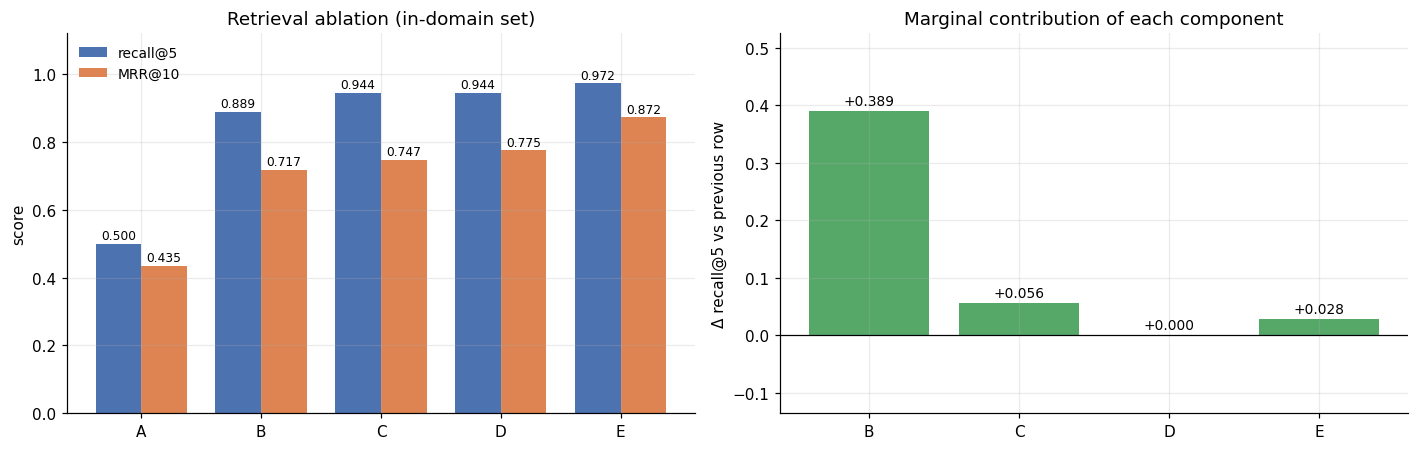

In [22]:
# ---- Figure 2: retrieval ablation ----
names = list(results)
short = [n.split("·")[0].strip() for n in names]
rec = [results[n]["recall@5"] for n in names]
mrr = [results[n]["mrr@10"] for n in names]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

x, w = np.arange(len(names)), 0.38
b1 = axes[0].bar(x - w/2, rec, w, label="recall@5", color=PALETTE[0])
b2 = axes[0].bar(x + w/2, mrr, w, label="MRR@10", color=PALETTE[1])
axes[0].bar_label(b1, fmt="%.3f", fontsize=8, padding=1)
axes[0].bar_label(b2, fmt="%.3f", fontsize=8, padding=1)
axes[0].set_xticks(x); axes[0].set_xticklabels(short)
axes[0].set_ylim(0, 1.12); axes[0].set_ylabel("score")
axes[0].set_title("Retrieval ablation (in-domain set)")
axes[0].legend(frameon=False, loc="upper left", fontsize=9)

deltas = [rec[i] - rec[i-1] for i in range(1, len(rec))]
cols = [PALETTE[2] if d >= 0 else PALETTE[3] for d in deltas]
b3 = axes[1].bar(short[1:], deltas, color=cols)
axes[1].bar_label(b3, fmt="%+.3f", fontsize=9, padding=2)
axes[1].axhline(0, color="black", lw=0.8)
pad = max(0.02, max(abs(min(deltas)), abs(max(deltas))) * 0.35)
axes[1].set_ylim(min(deltas) - pad, max(deltas) + pad)
axes[1].set_ylabel("Δ recall@5 vs previous row")
axes[1].set_title("Marginal contribution of each component")

plt.tight_layout(); plt.savefig(f"{FIG_DIR}/fig2_ablation.png", bbox_inches="tight"); plt.show()

,recall@5 (vi),recall@5 (en)
A · gte-small dense,0.481,0.556
B · bge-m3 dense,0.963,0.667
C · + BM25 (whitespace),0.963,0.889
D · + BM25 (pyvi segmented),0.963,0.889
E · + cross-encoder rerank,1.000,0.889


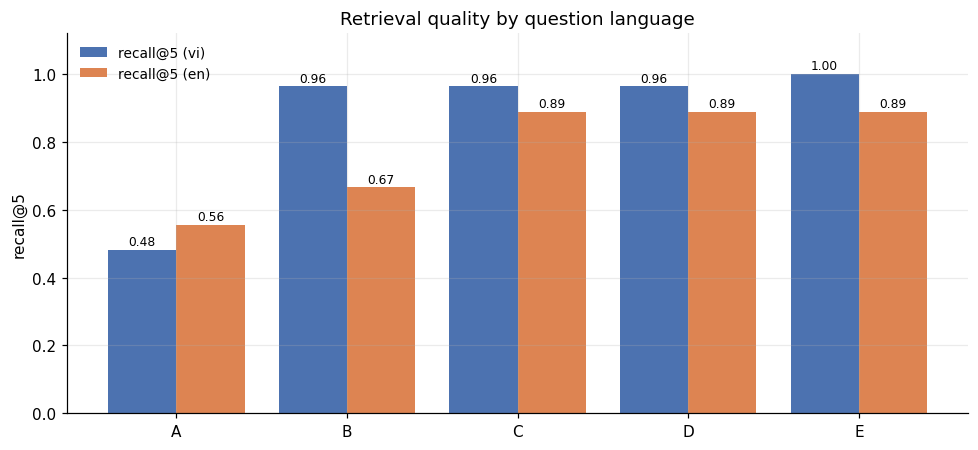

In [23]:
# ---- Figure 3: the same ablation split by question language ----
per_lang = {}
for lang in ("vi", "en"):
    subset = [d for d in INDOMAIN if d["lang"] == lang]
    if subset:
        per_lang[lang] = {n: evaluate_retrieval(fn, subset)["recall@5"]
                          for n, fn in CONFIGS.items()}

lang_df = pd.DataFrame(per_lang)
if not lang_df.empty:
    lang_df.columns = [f"recall@5 ({c})" for c in lang_df.columns]
    display(lang_df.style.format("{:.3f}"))

    fig, ax = plt.subplots(figsize=(9, 4.2))
    x = np.arange(len(lang_df)); w = 0.8 / max(len(lang_df.columns), 1)
    for j, col in enumerate(lang_df.columns):
        b = ax.bar(x + j*w - 0.4 + w/2, lang_df[col].values, w,
                   label=col, color=PALETTE[j])
        ax.bar_label(b, fmt="%.2f", fontsize=8, padding=1)
    ax.set_xticks(x); ax.set_xticklabels([n.split("·")[0].strip() for n in lang_df.index])
    ax.set_ylim(0, 1.12); ax.set_ylabel("recall@5")
    ax.set_title("Retrieval quality by question language")
    ax.legend(frameon=False, fontsize=9)
    plt.tight_layout(); plt.savefig(f"{FIG_DIR}/fig3_by_language.png", bbox_inches="tight")
    plt.show()
    lang_df.to_csv(os.path.join(WORK_DIR, "ablation_by_language.csv"))

### Reading the results

The A→B step answers RQ1 and is expected to be the largest single movement, concentrated
almost entirely in the Vietnamese column of Figure 3. A monolingual encoder applied to text
outside its training distribution does not degrade gracefully — it produces embeddings with
no useful structure, so retrieval over the Vietnamese half approaches chance.

C→D isolates segmentation. If the gain is small, it means the queries in the evaluation set
are largely conceptual rather than lexical; the value of segmentation grows with the share of
queries containing exact terms.

D→E is the reranking contribution (RQ3). Note the latency column: reranking is the dominant
cost per query, and the recall gain must be weighed against it.

E→F answers RQ4. A neutral or negative result here is informative rather than a failure —
it indicates the structural prefix already supplies the context the LLM would have written,
and the indexing cost is not repaid.

---
# §14 Experiment 2 — abstention: knowing when the corpus has no answer

This is the failure mode that matters most in deployment and is reported least often. A RAG
system asked something outside its corpus still retrieves five passages — nearest neighbours
always exist — and a language model handed five irrelevant passages and a question will very
often answer anyway, either by falling back on parametric memory or by stitching together
loosely related fragments. The output is fluent, cited, and wrong.

Instructing the model to refuse is necessary but not sufficient: it is a soft constraint that
competes with the model's strong prior toward helpfulness. This pipeline therefore uses three
independent layers, and the first is not a prompt at all.

**Layer 1 — calibrated retrieval gate (this section).** If the best cross-encoder score across
the retrieved passages falls below a threshold $\tau$, the pipeline refuses *before the reader
is ever invoked*. Because it is not a generative decision, it cannot be argued out of by a
persuasive question.

**Layer 2 — evidence grading (§18).** Above threshold but still weak, the reader is asked
whether the passages actually contain what the question requires, and the query is rewritten
and retried if not.

**Layer 3 — groundedness verification (§17).** After generation, every claim is checked
against the context, and an unsupported answer is regenerated or withdrawn.

### Choosing $\tau$ empirically

$\tau$ is not guessed. It is fitted on a calibration split and reported on a held-out split,
exactly as one would fit any decision threshold — because the tradeoff it controls is real:
raising $\tau$ rejects more out-of-domain questions but also refuses more answerable ones.

In [24]:
def retrieval_confidence(question: str, retriever: Optional[Retriever] = None,
                         top_k: int = FINAL_K) -> Tuple[float, List[Hit]]:
    '''Confidence = the best cross-encoder score among retrieved passages.'''
    hits = retrieve(question, top_k=top_k, retriever=retriever)
    return (max((h.score for h in hits), default=0.0), hits)


def score_questions(dataset: List[dict], label: str) -> np.ndarray:
    scores = []
    t0 = time.time()
    for i, d in enumerate(dataset):
        s, _ = retrieval_confidence(d["question"])
        scores.append(s)
    print(f"{label:12s} n={len(scores):3d}  "
          f"mean {np.mean(scores):.3f}  median {np.median(scores):.3f}  "
          f"p10 {np.percentile(scores,10):.3f}  p90 {np.percentile(scores,90):.3f}  "
          f"({time.time()-t0:.0f}s)")
    return np.asarray(scores)


scores_in  = score_questions(INDOMAIN, "in-domain")
scores_ood = score_questions(OOD, "out-of-domain")

overlap = np.mean(scores_ood > np.percentile(scores_in, 10))
print(f"\nseparation: {100*(1-overlap):.0f}% of OOD questions score below the "
      f"10th percentile of in-domain questions")

in-domain    n= 36  mean 0.928  median 0.992  p10 0.752  p90 1.000  (143s)
out-of-domain n= 24  mean 0.015  median 0.001  p10 0.000  p90 0.028  (91s)

separation: 100% of OOD questions score below the 10th percentile of in-domain questions


In [25]:
# ---- Calibration / held-out split -----------------------------------------------------
def split_half(arr: np.ndarray, frac: float = CALIBRATION_SPLIT):
    idx = np.random.RandomState(SEED).permutation(len(arr))
    cut = int(len(arr) * frac)
    return arr[idx[:cut]], arr[idx[cut:]]


cal_in,  test_in  = split_half(scores_in)
cal_ood, test_ood = split_half(scores_ood)
print(f"calibration: {len(cal_in)} in-domain / {len(cal_ood)} OOD")
print(f"held out   : {len(test_in)} in-domain / {len(test_ood)} OOD")


def gate_metrics(tau: float, pos: np.ndarray, neg: np.ndarray) -> Dict[str, float]:
    '''pos = answerable questions, neg = out-of-domain. "Positive" = the system answers.'''
    tp = float((pos >= tau).sum())      # answerable, answered
    fn = float((pos <  tau).sum())      # answerable, wrongly refused
    fp = float((neg >= tau).sum())      # unanswerable, wrongly answered
    tn = float((neg <  tau).sum())      # unanswerable, correctly refused
    prec = tp / max(tp + fp, 1e-9)
    rec  = tp / max(tp + fn, 1e-9)
    return {"tau": tau, "precision": prec, "recall": rec,
            "f1": 2 * prec * rec / max(prec + rec, 1e-9),
            "ood_rejection": tn / max(tn + fp, 1e-9),
            "accuracy": (tp + tn) / max(tp + tn + fp + fn, 1e-9),
            "tp": tp, "fn": fn, "fp": fp, "tn": tn}


taus = np.linspace(0.01, 0.99, 197)
sweep = pd.DataFrame([gate_metrics(t, cal_in, cal_ood) for t in taus])

TAU_F1 = float(sweep.loc[sweep["f1"].idxmax(), "tau"])
safe = sweep[sweep["recall"] >= 0.90]
TAU_SAFE = float(safe.loc[safe["ood_rejection"].idxmax(), "tau"]) if len(safe) else TAU_F1

ANSWER_THRESHOLD = TAU_F1          # switch to TAU_SAFE for a recall-preserving deployment
print(f"tau (max F1)                         = {TAU_F1:.3f}")
print(f"tau (max OOD rejection @ recall>=0.9)= {TAU_SAFE:.3f}")
print(f"\nselected ANSWER_THRESHOLD = {ANSWER_THRESHOLD:.3f}")
display(pd.DataFrame([gate_metrics(ANSWER_THRESHOLD, cal_in, cal_ood)])
        [["tau", "precision", "recall", "f1", "ood_rejection", "accuracy"]]
        .style.format("{:.3f}"))

calibration: 18 in-domain / 12 OOD
held out   : 18 in-domain / 12 OOD
tau (max F1)                         = 0.055
tau (max OOD rejection @ recall>=0.9)= 0.055

selected ANSWER_THRESHOLD = 0.055


,tau,precision,recall,f1,ood_rejection,accuracy
0,0.055,1.000,1.000,1.000,1.000,1.000


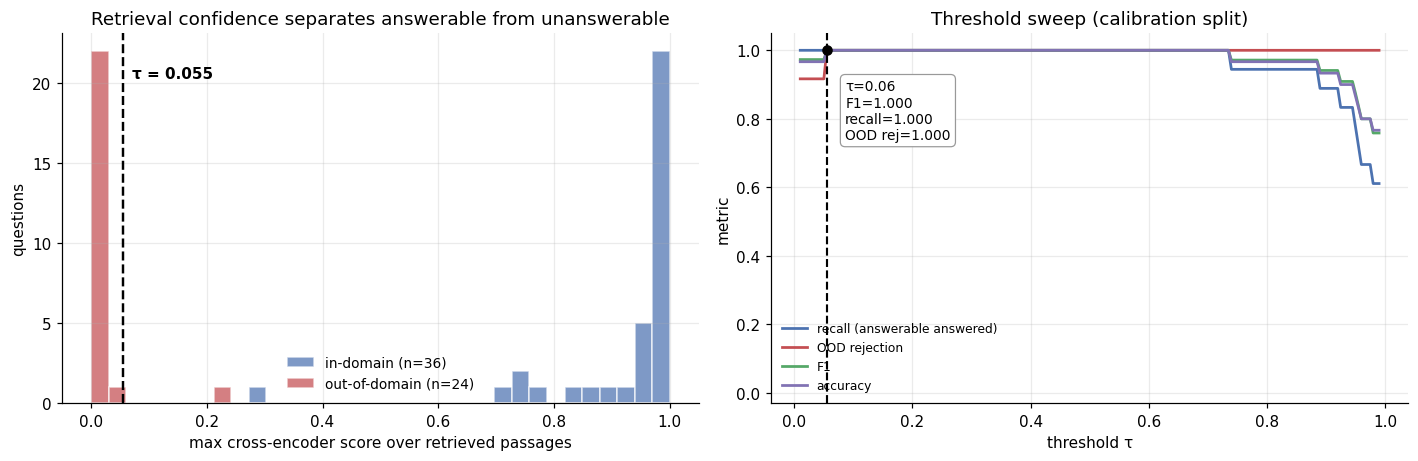

In [26]:
# ---- Figure 4: score separation and threshold sweep ----
fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))

bins = np.linspace(0, 1, 34)
axes[0].hist(scores_in,  bins=bins, alpha=0.72, label=f"in-domain (n={len(scores_in)})",
             color=PALETTE[0], edgecolor="white")
axes[0].hist(scores_ood, bins=bins, alpha=0.72, label=f"out-of-domain (n={len(scores_ood)})",
             color=PALETTE[3], edgecolor="white")
axes[0].axvline(ANSWER_THRESHOLD, color="black", ls="--", lw=1.6)
axes[0].annotate(f"τ = {ANSWER_THRESHOLD:.3f}", xy=(ANSWER_THRESHOLD, axes[0].get_ylim()[1]*0.88),
                 xytext=(6, 0), textcoords="offset points", fontsize=10, fontweight="bold")
axes[0].set_xlabel("max cross-encoder score over retrieved passages")
axes[0].set_ylabel("questions")
axes[0].set_title("Retrieval confidence separates answerable from unanswerable")
axes[0].legend(frameon=False, fontsize=9)

for key, col, lab in [("recall", PALETTE[0], "recall (answerable answered)"),
                      ("ood_rejection", PALETTE[3], "OOD rejection"),
                      ("f1", PALETTE[2], "F1"),
                      ("accuracy", PALETTE[4], "accuracy")]:
    axes[1].plot(sweep["tau"], sweep[key], label=lab, color=col, lw=1.8)
axes[1].axvline(ANSWER_THRESHOLD, color="black", ls="--", lw=1.4)
best = gate_metrics(ANSWER_THRESHOLD, cal_in, cal_ood)
axes[1].scatter([ANSWER_THRESHOLD], [best["f1"]], color="black", zorder=5, s=35)
axes[1].annotate(f"τ={ANSWER_THRESHOLD:.2f}\nF1={best['f1']:.3f}\nrecall={best['recall']:.3f}\n"
                 f"OOD rej={best['ood_rejection']:.3f}",
                 xy=(ANSWER_THRESHOLD, best["f1"]), xytext=(12, -58),
                 textcoords="offset points", fontsize=9,
                 bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="0.6", lw=0.8))
axes[1].set_xlabel("threshold τ"); axes[1].set_ylabel("metric")
axes[1].set_ylim(-0.03, 1.05)
axes[1].set_title("Threshold sweep (calibration split)")
axes[1].legend(frameon=False, fontsize=8, loc="lower left")

plt.tight_layout(); plt.savefig(f"{FIG_DIR}/fig4_abstention.png", bbox_inches="tight"); plt.show()
sweep.to_csv(os.path.join(WORK_DIR, "abstention_sweep.csv"), index=False)

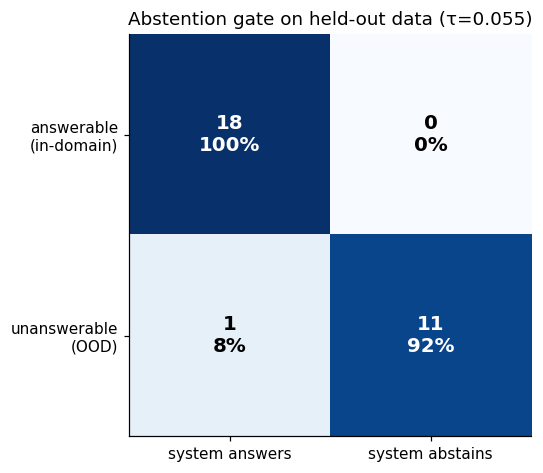

,precision,recall,f1,ood_rejection,accuracy
held-out,0.947,1.000,0.973,0.917,0.967



Of 18 answerable questions, 0 were refused (false abstentions).
Of 12 unanswerable questions, 1 were answered (the failures the gate exists to prevent).


In [27]:
# ---- Figure 5: held-out confusion matrix ----
held = gate_metrics(ANSWER_THRESHOLD, test_in, test_ood)
cm = np.array([[held["tp"], held["fn"]], [held["fp"], held["tn"]]])

fig, ax = plt.subplots(figsize=(5.2, 4.4))
im = ax.imshow(cm / cm.sum(axis=1, keepdims=True), cmap="Blues", vmin=0, vmax=1)
ax.set_xticks([0, 1]); ax.set_xticklabels(["system answers", "system abstains"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["answerable\n(in-domain)", "unanswerable\n(OOD)"])
for i in range(2):
    for j in range(2):
        frac = cm[i, j] / max(cm[i].sum(), 1)
        ax.text(j, i, f"{int(cm[i,j])}\n{frac:.0%}", ha="center", va="center", fontsize=13,
                color="white" if frac > 0.5 else "black", fontweight="bold")
ax.set_title(f"Abstention gate on held-out data (τ={ANSWER_THRESHOLD:.3f})")
ax.grid(False)
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/fig5_confusion.png", bbox_inches="tight"); plt.show()

display(pd.DataFrame([{k: held[k] for k in
                       ["precision", "recall", "f1", "ood_rejection", "accuracy"]}],
                     index=["held-out"]).style.format("{:.3f}"))
print(f"\nOf {int(held['tp']+held['fn'])} answerable questions, {int(held['fn'])} were refused "
      f"(false abstentions).")
print(f"Of {int(held['fp']+held['tn'])} unanswerable questions, {int(held['fp'])} were answered "
      f"(the failures the gate exists to prevent).")

---
# §15 Query understanding

Retrieval quality is bounded by the query it receives, and the user's phrasing is often not
the best query. Three transformations are applied before retrieval.

**Routing** distinguishes questions requiring the corpus from conversational turns that do
not, so that greetings and meta-questions are not forced through a retrieval pipeline that
will return irrelevant passages and trip the abstention gate.

**Decomposition** handles multi-hop questions. A question spanning two topics has no single
best passage, and a single embedding of it sits between both clusters — retrieving neither
well. Splitting into sub-queries and fusing the candidate lists retrieves both.

**Rewriting** is the recovery path used by the loop in §18: when retrieval returns nothing
sufficient, the question is restated with different vocabulary and retried.

In [28]:
ROUTE_PROMPT = (
    "Classify the user's message into exactly one label:\n"
    "SIMPLE   - a factual question about a specific topic\n"
    "MULTIHOP - a question requiring information about two or more distinct topics\n"
    "CHITCHAT - a greeting, thanks, or a question about the assistant itself\n"
    "Reply with only the label."
)


def route_query(question: str) -> str:
    v = llm_chat([{"role": "system", "content": ROUTE_PROMPT},
                  {"role": "user", "content": question}],
                 max_new_tokens=6, tag="route").upper()
    for label in ("MULTIHOP", "CHITCHAT", "SIMPLE"):
        if label in v:
            return label
    return "SIMPLE"


def decompose(question: str, max_parts: int = MAX_SUBQUERIES) -> List[str]:
    out = llm_chat([
        {"role": "system", "content":
            f"Split the question into at most {max_parts} independent sub-questions, one per "
            "line, no numbering, no commentary. Keep the original language."},
        {"role": "user", "content": question}], max_new_tokens=120, tag="decompose")
    parts = [l.strip(" -•\t") for l in out.split("\n") if len(l.strip()) > 8][:max_parts]
    return parts or [question]


def rewrite_query(question: str, attempted: List[str]) -> str:
    out = llm_chat([
        {"role": "system", "content":
            "The search below returned nothing useful. Rewrite the question as a better search "
            "query: use synonyms and domain terminology, drop conversational filler, keep the "
            "original language. Return only the rewritten query."},
        {"role": "user", "content":
            f"Question: {question}\nAlready tried: {'; '.join(attempted)}"}],
        max_new_tokens=60, tag="rewrite")
    return out.split("\n")[0].strip().strip('"') or question


for q in ["Xin chào!", "Chuyển đổi số là gì?",
          "Compare the security considerations of cloud computing with the barriers to digital transformation"]:
    print(f"{route_query(q):9s} <- {q[:70]}")

CHITCHAT  <- Xin chào!
SIMPLE    <- Chuyển đổi số là gì?
MULTIHOP  <- Compare the security considerations of cloud computing with the barrie


---
# §16 Generation with verifiable citations

The reader receives numbered passages, each labelled with its source file and page, and is
required to cite the passages it uses. Because the numbering is backed by real metadata, a
citation resolves to a location a human can open and check — the difference between a citation
and the appearance of one.

The prompt is assembled as a message list and rendered through the model's chat template
rather than by string formatting. Format-string assembly breaks the moment a retrieved passage
contains a brace, which technical PDFs frequently do.

The system prompt also encodes the abstention requirement in both corpus languages. It is the
weakest of the three layers on its own, but it is free and it composes with the other two.

In [29]:
SYSTEM_PROMPT = (
    "You answer questions strictly from the numbered context passages you are given.\n"
    "Rules:\n"
    "1. Use ONLY the passages. Never use prior knowledge, even if you are confident.\n"
    "2. Cite every claim inline as [1], [2], matching the passage numbers.\n"
    "3. If the passages do not contain the answer, reply with exactly: INSUFFICIENT_CONTEXT\n"
    "   Do not guess, do not partially answer, do not speculate.\n"
    "4. Answer in the same language as the question.\n"
    "Bạn chỉ được trả lời dựa trên các đoạn văn được cung cấp. Nếu không đủ thông tin, "
    "hãy trả lời đúng: INSUFFICIENT_CONTEXT"
)

ABSTAIN_MSG = {
    "en": "I could not find this in the indexed documents, so I cannot answer it. "
          "The corpus covers {topics}.",
    "vi": "Tôi không tìm thấy thông tin này trong các tài liệu đã được lập chỉ mục, "
          "nên tôi không thể trả lời. Bộ tài liệu bao gồm: {topics}.",
}
CORPUS_TOPICS = ", ".join(sorted({os.path.splitext(c.source)[0].replace("-", " ")
                                  for c in CHUNKS}))


def abstain_text(question: str) -> str:
    lang = "vi" if is_vietnamese(question) else "en"
    return ABSTAIN_MSG[lang].format(topics=CORPUS_TOPICS)


def build_context(hits: List[Hit]) -> str:
    return "\n\n".join(
        f"[{i}] (source: {h.chunk.source}, page {h.chunk.page})\n{h.chunk.text}"
        for i, h in enumerate(hits, start=1))


def generate_answer(question: str, hits: List[Hit], extra: Optional[List[dict]] = None) -> str:
    messages = [{"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content":
                    f"Context:\n{build_context(hits)}\n\n---\nQuestion: {question}"}]
    messages += (extra or [])
    return llm_chat(messages, max_new_tokens=512, tag="generate")


CITE_RE = re.compile(r"\[(\d+)\]")


def cited_indices(answer: str, n_passages: int) -> List[int]:
    return sorted({int(m) for m in CITE_RE.findall(answer) if 1 <= int(m) <= n_passages})

---
# §17 Groundedness verification

Faithfulness is usually reported as an offline metric, computed after the fact over a
benchmark. It is considerably more useful as an **inline gate**: check before the answer
reaches the user, and regenerate under a stricter instruction if the check fails. The cost is
one additional forward pass per query.

The check is deliberately claim-level rather than holistic — a whole-answer judgement is easy
for a model to wave through, whereas enumerating claims and testing each one forces the
failure to surface.

In [30]:
@torch.inference_mode()
def check_grounded(answer: str, context: str) -> Optional[bool]:
    if answer.strip().startswith("INSUFFICIENT_CONTEXT"):
        return True
    v = llm_chat([
        {"role": "system", "content":
            "You are a strict verifier. List nothing. Decide whether EVERY factual claim in the "
            "answer is directly supported by the context. Any claim that is not stated in the "
            "context makes the whole answer unsupported. "
            "Reply with exactly one word: SUPPORTED or UNSUPPORTED."},
        {"role": "user", "content": f"Context:\n{context}\n\n---\nAnswer:\n{answer}"}],
        max_new_tokens=6, tag="groundedness").upper()
    if "UNSUPPORTED" in v:
        return False
    if "SUPPORTED" in v:
        return True
    return None


def grade_sufficiency(question: str, hits: List[Hit]) -> bool:
    '''Do the retrieved passages actually contain what the question asks for?'''
    ctx = "\n\n".join(h.chunk.text[:900] for h in hits[:3])
    v = yes_no(f"Context:\n{ctx}\n\n---\nQuestion: {question}\n\n"
               "Do these passages contain enough information to answer the question?",
               system="Reply with exactly one word: YES or NO.", tag="grade")
    return bool(v)

---
# §18 Orchestration — the retrieve, grade, rewrite loop

The stages above are composed into a state machine rather than a straight line. A single-pass
pipeline sets its accuracy ceiling at first-stage retrieval: if the initial query phrasing
misses, nothing downstream can recover. Allowing the system to observe that its evidence is
inadequate and try a different query is what converts a fixed pipeline into something that can
correct itself.

Every run returns a **trace** of the states visited, which makes the system's behaviour
inspectable — for debugging, and for reporting how often each recovery path actually fires.

```text
  route ──chitchat──────────────────────────────────► direct reply
    │ simple / multihop
    ▼
  decompose (multihop only)
    ▼
  ┌► retrieve ──► confidence < τ ?  ──yes──► abstain
  │      │ no
  │      ▼
  │   grade evidence ──insufficient──► rewrite ──┐
  │                                              │  (up to MAX_RETRIEVAL_ROUNDS)
  └──────────────────────────────────────────────┘
         │ sufficient
         ▼
      generate ──► groundedness ──unsupported──► regenerate ──► still bad ──► abstain
                        │ supported
                        ▼
                   answer + citations
```

In [31]:
@dataclass
class RagResult:
    question: str
    answer: str
    hits: List[Hit] = field(default_factory=list)
    abstained: bool = False
    grounded: Optional[bool] = None
    confidence: float = 0.0
    rounds: int = 0
    route: str = "SIMPLE"
    trace: List[str] = field(default_factory=list)
    citations: List[dict] = field(default_factory=list)
    seconds: float = 0.0


def answer_question(question: str, top_k: int = FINAL_K, tau: Optional[float] = None,
                    use_router: bool = True, verbose: bool = False) -> RagResult:
    tau = ANSWER_THRESHOLD if tau is None else tau
    t0 = time.time()
    res = RagResult(question=question, answer="")
    log = res.trace.append

    # --- route ---------------------------------------------------------------
    res.route = route_query(question) if use_router else "SIMPLE"
    log(f"route={res.route}")
    if res.route == "CHITCHAT":
        res.answer = llm_chat([
            {"role": "system", "content":
                "You are a document question-answering assistant. Reply in one short sentence "
                "in the user's language, and mention that you can only answer questions about "
                f"the indexed documents ({CORPUS_TOPICS})."},
            {"role": "user", "content": question}], max_new_tokens=90, tag="chitchat")
        res.seconds = time.time() - t0
        log("direct_reply")
        return res

    queries = decompose(question) if res.route == "MULTIHOP" else [question]
    if len(queries) > 1:
        log(f"decomposed->{len(queries)}")

    attempted: List[str] = []
    hits: List[Hit] = []
    for rnd in range(1, MAX_RETRIEVAL_ROUNDS + 1):
        res.rounds = rnd
        cand: List[int] = []
        for q in queries:
            cand.extend(RETRIEVER.candidates(q, CANDIDATES_K))
        seen, dedup = set(), []
        for i in cand:
            if i not in seen:
                seen.add(i); dedup.append(i)
        hits = rerank(question, dedup, top_k)
        res.confidence = max((h.score for h in hits), default=0.0)
        log(f"round{rnd}:retrieved={len(hits)},conf={res.confidence:.3f}")

        if res.confidence < tau:
            log("gate=below_threshold")
        elif grade_sufficiency(question, hits):
            log("grade=sufficient")
            break
        else:
            log("grade=insufficient")

        if rnd < MAX_RETRIEVAL_ROUNDS:
            attempted.extend(queries)
            queries = [rewrite_query(question, attempted)]
            log(f"rewrite->{queries[0][:60]}")
        else:
            res.abstained = True

    res.hits = hits
    if res.abstained or res.confidence < tau:
        res.abstained = True
        res.answer = abstain_text(question)
        log("ABSTAIN")
        res.seconds = time.time() - t0
        return res

    # --- generate ------------------------------------------------------------
    context = build_context(hits)
    answer = generate_answer(question, hits)
    log("generated")

    if answer.strip().startswith("INSUFFICIENT_CONTEXT"):
        res.abstained = True
        res.answer = abstain_text(question)
        log("reader_declined->ABSTAIN")
        res.seconds = time.time() - t0
        return res

    # --- verify --------------------------------------------------------------
    res.grounded = check_grounded(answer, context)
    log(f"grounded={res.grounded}")
    if res.grounded is False:
        answer = generate_answer(question, hits, extra=[
            {"role": "assistant", "content": answer},
            {"role": "user", "content":
                "Some claims are not supported by the passages. Rewrite using only what the "
                "passages state, cite every claim, and drop anything you cannot cite. If "
                "nothing can be supported, reply exactly INSUFFICIENT_CONTEXT."}])
        res.grounded = check_grounded(answer, context)
        log(f"regenerated,grounded={res.grounded}")
        if answer.strip().startswith("INSUFFICIENT_CONTEXT") or res.grounded is False:
            res.abstained = True
            res.answer = abstain_text(question)
            log("ABSTAIN_after_verification")
            res.seconds = time.time() - t0
            return res

    res.answer = answer
    used = cited_indices(answer, len(hits))
    res.citations = [{"n": i, "source": hits[i-1].chunk.source, "page": hits[i-1].chunk.page,
                      "score": round(hits[i-1].score, 3)} for i in used]
    res.seconds = time.time() - t0
    return res


def show(res: RagResult):
    print("=" * 96)
    print("Q:", res.question)
    print("-" * 96)
    print(res.answer)
    print("-" * 96)
    flag = "ABSTAINED" if res.abstained else "answered"
    print(f"{flag} | confidence {res.confidence:.3f} (τ={ANSWER_THRESHOLD:.3f}) | "
          f"grounded={res.grounded} | rounds={res.rounds} | {res.seconds:.1f}s")
    for c in res.citations:
        print(f"   [{c['n']}] {c['source']} — page {c['page']}  (score {c['score']})")
    print("trace:", " → ".join(res.trace))
    print()

In [32]:
# ---- Qualitative demonstration: in-domain, then deliberately out-of-domain ----
demo_in  = [d["question"] for d in INDOMAIN[:2]]
demo_ood = ["Ai là tác giả của Truyện Kiều?",
            "What is the best way to cook a medium-rare steak?"]

print("### IN-DOMAIN " + "#" * 80 + "\n")
for q in demo_in:
    show(answer_question(q))

print("### OUT-OF-DOMAIN — the system must refuse " + "#" * 52 + "\n")
for q in demo_ood:
    show(answer_question(q))

### IN-DOMAIN ################################################################################

Q: Tại sao công ty du lịch này quyết định thay đổi kích thước bàn ăn trong nhà ăn của mình?
------------------------------------------------------------------------------------------------
Tôi không tìm thấy thông tin này trong các tài liệu đã được lập chỉ mục, nên tôi không thể trả lời. Bộ tài liệu bao gồm: cam nang chuyen doi so, cloudsplit, giao trinh co so du lieu ngo tran thanh thao csdl, quy che hoc tap.
------------------------------------------------------------------------------------------------
ABSTAINED | confidence 1.000 (τ=0.055) | grounded=None | rounds=2 | 20.5s
trace: route=SIMPLE → round1:retrieved=5,conf=1.000 → grade=insufficient → rewrite->Why did this travel company decide to change the size of tab → round2:retrieved=5,conf=1.000 → grade=insufficient → ABSTAIN

Q: Chuyển đổi số trong lĩnh vực nào được trình bày chi tiết nhất trong đoạn văn này?
-------------------------

in-domain:
  in  1/10 ABSTAIN conf=1.000
  in  2/10 ABSTAIN conf=0.867
  in  3/10 answer  conf=1.000
  in  4/10 answer  conf=0.969
  in  5/10 answer  conf=1.000
  in  6/10 answer  conf=1.000
  in  7/10 answer  conf=1.000
  in  8/10 ABSTAIN conf=0.711
  in  9/10 answer  conf=0.996
  in  10/10 answer  conf=0.957
out-of-domain:
  ood 1/10 ABSTAIN conf=0.000
  ood 2/10 ABSTAIN conf=0.001
  ood 3/10 ABSTAIN conf=0.000
  ood 4/10 ABSTAIN conf=0.002
  ood 5/10 ABSTAIN conf=0.002
  ood 6/10 ABSTAIN conf=0.000
  ood 7/10 ABSTAIN conf=0.000
  ood 8/10 ABSTAIN conf=0.001
  ood 9/10 ABSTAIN conf=0.003
  ood 10/10 ABSTAIN conf=0.000


,set,n,answered,abstained,mean confidence,mean seconds
0,in-domain (answerable),10,7,3,0.950,41.2
1,out-of-domain (unanswerable),10,0,10,0.001,9.6


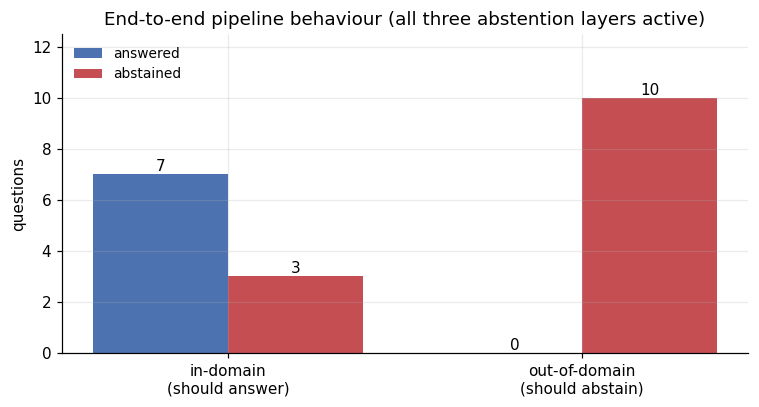

In [33]:
# ---- End-to-end abstention behaviour, measured on the held-out questions ----
def run_batch(dataset: List[dict], n: int, label: str) -> List[RagResult]:
    out = []
    for d in dataset[:n]:
        out.append(answer_question(d["question"]))
        print(f"  {label} {len(out)}/{min(n,len(dataset))} "
              f"{'ABSTAIN' if out[-1].abstained else 'answer '} "
              f"conf={out[-1].confidence:.3f}", flush=True)
    return out


N_BEHAVIOUR = 10
print("in-domain:")
res_in = run_batch(INDOMAIN, N_BEHAVIOUR, "in ")
print("out-of-domain:")
res_ood = run_batch(OOD, N_BEHAVIOUR, "ood")

behaviour = pd.DataFrame([
    {"set": "in-domain (answerable)", "n": len(res_in),
     "answered": sum(not r.abstained for r in res_in),
     "abstained": sum(r.abstained for r in res_in),
     "mean confidence": np.mean([r.confidence for r in res_in]),
     "mean seconds": np.mean([r.seconds for r in res_in])},
    {"set": "out-of-domain (unanswerable)", "n": len(res_ood),
     "answered": sum(not r.abstained for r in res_ood),
     "abstained": sum(r.abstained for r in res_ood),
     "mean confidence": np.mean([r.confidence for r in res_ood]),
     "mean seconds": np.mean([r.seconds for r in res_ood])},
])
display(behaviour.style.format({"mean confidence": "{:.3f}", "mean seconds": "{:.1f}"}))

fig, ax = plt.subplots(figsize=(7, 3.8))
labels = ["in-domain\n(should answer)", "out-of-domain\n(should abstain)"]
answered  = [behaviour.loc[0, "answered"],  behaviour.loc[1, "answered"]]
abstained = [behaviour.loc[0, "abstained"], behaviour.loc[1, "abstained"]]
x = np.arange(2); w = 0.38
b1 = ax.bar(x - w/2, answered,  w, label="answered",  color=PALETTE[0])
b2 = ax.bar(x + w/2, abstained, w, label="abstained", color=PALETTE[3])
ax.bar_label(b1, fmt="%d", fontsize=10); ax.bar_label(b2, fmt="%d", fontsize=10)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("questions"); ax.set_ylim(0, N_BEHAVIOUR * 1.25)
ax.set_title("End-to-end pipeline behaviour (all three abstention layers active)")
ax.legend(frameon=False, fontsize=9)
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/fig6_behaviour.png", bbox_inches="tight"); plt.show()

---
# §19 Experiment 3 — end-to-end evaluation with RAGAS

Retrieval metrics measure whether the right passage was found. They say nothing about whether
the generated answer used it, invented anything, or addressed the question. RAGAS supplies four
reference metrics that cover generation as well as retrieval:

| Metric | Question it answers | Depends on |
|---|---|---|
| **Faithfulness** | Is every claim in the answer supported by the retrieved context? | answer, contexts |
| **Answer relevancy** | Does the answer address the question that was asked? | question, answer |
| **Context precision** | Are the retrieved passages actually useful, and ranked well? | question, contexts, reference |
| **Context recall** | Does the retrieved context cover everything the reference answer states? | contexts, reference |

Faithfulness and answer relevancy together are the pair that detects hallucination: a fluent
answer to the wrong question scores low on relevancy; a fluent answer containing invented facts
scores low on faithfulness.

RAGAS defaults to OpenAI models as judge. Here it is wired to the local reader and encoder
instead, so the notebook needs no API key. That has a real methodological cost — the judge
shares the generator's blind spots and will be biased toward approving its own output — and it
is recorded as a limitation in §22.

Because the official package's API has changed substantially across releases, an equivalent
native implementation of the same four metric definitions is provided as a fallback. Both
paths produce identical output structures, so the analysis below runs either way; which one
executed is reported in `EVAL_BACKEND`.

In [34]:
# ---- Build the evaluation dataset: run the full pipeline, then a reference answer ----
def build_eval_dataset(n: int = RAGAS_SAMPLES) -> pd.DataFrame:
    pool = [d for d in INDOMAIN if d.get("chunk_id") is not None][:n]
    rows = []
    for i, d in enumerate(pool, 1):
        res = answer_question(d["question"], use_router=False)
        gold = CHUNKS[d["chunk_id"]]
        reference = llm_chat([
            {"role": "system", "content":
                "Answer the question using only the passage. Be concise and factual. "
                "Answer in the language of the question."},
            {"role": "user", "content": f"Passage:\n{gold.text}\n\nQuestion: {d['question']}"}],
            max_new_tokens=200, tag="reference")
        rows.append({
            "question": d["question"],
            "answer": res.answer,
            "contexts": [h.chunk.text for h in res.hits] or [gold.text],
            "reference": reference,
            "ground_truth": reference,          # alias for older ragas releases
            "lang": d["lang"],
            "abstained": res.abstained,
        })
        print(f"  {i}/{len(pool)} {'ABSTAIN' if res.abstained else 'answered'}", flush=True)
    return pd.DataFrame(rows)


EVAL_DF = build_eval_dataset()
EVAL_DF.to_json(os.path.join(WORK_DIR, "eval_generation.json"),
                orient="records", force_ascii=False, indent=2)
print(f"\n{len(EVAL_DF)} samples | {EVAL_DF['abstained'].sum()} abstentions")
display(EVAL_DF[["question", "answer", "abstained"]].head(4))

  1/12 ABSTAIN
  2/12 ABSTAIN
  3/12 answered
  4/12 answered
  5/12 answered
  6/12 answered
  7/12 answered
  8/12 ABSTAIN
  9/12 answered
  10/12 answered
  11/12 ABSTAIN
  12/12 answered

12 samples | 4 abstentions


,question,answer,abstained
0,Tại sao công ty du lịch này quyết định thay đổ...,Tôi không tìm thấy thông tin này trong các tài...,True
1,Chuyển đổi số trong lĩnh vực nào được trình bà...,Tôi không tìm thấy thông tin này trong các tài...,True
2,Ứng dụng này giúp cải thiện điều gì ở người bệ...,Ứng dụng này giúp cải thiện thuận tiện cho ngư...,False
3,Kinh tế số giúp người dân bán hàng đến được vớ...,Kinh tế số cho phép người dân bán hàng cho hàn...,False


In [35]:
!pip install -q ragas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 466.5/466.5 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.5/252.5 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 49.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 561.7/561.7 kB 37.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.1/122.1 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 71.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 97.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 49.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the sour

In [36]:
EVAL_BACKEND, SCORES, per_sample = None, {}, None

try:
    from ragas import evaluate as ragas_evaluate
    from ragas.metrics import faithfulness, answer_relevancy, context_precision, context_recall
    from ragas.llms import LangchainLLMWrapper
    from ragas.embeddings import LangchainEmbeddingsWrapper
    from langchain_core.embeddings import Embeddings
    from langchain_huggingface import HuggingFacePipeline
    from transformers import pipeline as hf_pipeline
    from datasets import Dataset

    class STEmbeddings(Embeddings):
        '''Reuse the already-loaded encoder instead of loading a second copy.'''
        def embed_documents(self, texts):
            return embedder.encode(texts, normalize_embeddings=True).astype(float).tolist()
        def embed_query(self, text):
            return embedder.encode([text], normalize_embeddings=True)[0].astype(float).tolist()

    judge_pipe = hf_pipeline("text-generation", model=reader, tokenizer=reader_tok,
                             max_new_tokens=320, do_sample=False,
                             return_full_text=False)
    judge_llm = LangchainLLMWrapper(HuggingFacePipeline(pipeline=judge_pipe))
    judge_emb = LangchainEmbeddingsWrapper(STEmbeddings())

    ds = Dataset.from_pandas(EVAL_DF[["question", "answer", "contexts", "reference",
                                      "ground_truth"]])
    ragas_out = ragas_evaluate(
        ds, metrics=[faithfulness, answer_relevancy, context_precision, context_recall],
        llm=judge_llm, embeddings=judge_emb, raise_exceptions=False,
    )
    per_sample = ragas_out.to_pandas()
    for m in ("faithfulness", "answer_relevancy", "context_precision", "context_recall"):
        if m in per_sample.columns:
            SCORES[m] = float(pd.to_numeric(per_sample[m], errors="coerce").mean())
    if not SCORES or all(np.isnan(v) for v in SCORES.values()):
        raise RuntimeError("ragas returned no usable scores")
    EVAL_BACKEND = "ragas"
    print("RAGAS completed:", SCORES)

except Exception as e:
    EVAL_BACKEND, SCORES, per_sample = None, {}, None
    print(f"RAGAS unavailable or failed ({type(e).__name__}: {str(e)[:160]})")
    print("falling back to the native implementation in the next cell.")

RAGAS unavailable or failed (ModuleNotFoundError: No module named 'langchain_community.chat_models.vertexai')
falling back to the native implementation in the next cell.


In [37]:
# ---- Native implementation of the same four metric definitions -------------------------
def split_claims(text: str, max_claims: int = 6) -> List[str]:
    out = llm_chat([
        {"role": "system", "content":
            f"Break the text into at most {max_claims} short standalone factual claims, one per "
            "line, no numbering. Drop citation markers."},
        {"role": "user", "content": text[:2500]}], max_new_tokens=220, tag="claims")
    claims = [re.sub(r"^[\-\d\.\)\s•]+", "", l).strip()
              for l in out.split("\n") if len(l.strip()) > 12]
    return claims[:max_claims] or [text[:300]]


def m_faithfulness(answer: str, contexts: List[str]) -> float:
    ctx = "\n\n".join(contexts)[:6000]
    claims = split_claims(answer)
    ok = [yes_no(f"Context:\n{ctx}\n\n---\nClaim: {c}\n\nIs the claim supported by the context?",
                 tag="m_faith") for c in claims]
    ok = [v for v in ok if v is not None]
    return float(np.mean(ok)) if ok else 0.0


def m_answer_relevancy(question: str, answer: str, n: int = 3) -> float:
    out = llm_chat([
        {"role": "system", "content":
            f"Write {n} different questions that the given answer would be a correct answer to. "
            "One per line, no numbering, same language as the answer."},
        {"role": "user", "content": answer[:2000]}], max_new_tokens=140, tag="m_relev")
    gen = [l.strip(" -•") for l in out.split("\n") if len(l.strip()) > 8][:n]
    if not gen:
        return 0.0
    v = embedder.encode([question] + gen, normalize_embeddings=True)
    return float(np.clip(np.mean(v[1:] @ v[0]), 0.0, 1.0))


def m_context_precision(question: str, contexts: List[str], reference: str) -> float:
    rel = []
    for c in contexts:
        v = yes_no(f"Question: {question}\nReference answer: {reference[:800]}\n\n"
                   f"Passage:\n{c[:1600]}\n\nWas this passage useful for producing the "
                   "reference answer?", tag="m_prec")
        rel.append(1 if v else 0)
    if not any(rel):
        return 0.0
    precs = [sum(rel[:i+1]) / (i+1) for i, r in enumerate(rel) if r]
    return float(np.mean(precs))


def m_context_recall(contexts: List[str], reference: str) -> float:
    ctx = "\n\n".join(contexts)[:6000]
    sents = [s.strip() for s in re.split(r"(?<=[.!?])\s+", reference) if len(s.strip()) > 15]
    if not sents:
        return 0.0
    ok = [yes_no(f"Context:\n{ctx}\n\n---\nSentence: {s}\n\n"
                 "Can this sentence be attributed to the context?", tag="m_recall")
          for s in sents[:6]]
    ok = [v for v in ok if v is not None]
    return float(np.mean(ok)) if ok else 0.0


if EVAL_BACKEND != "ragas":
    t0 = time.time()
    rows = []
    for i, r in EVAL_DF.iterrows():
        rows.append({
            "faithfulness":      m_faithfulness(r["answer"], r["contexts"]),
            "answer_relevancy":  m_answer_relevancy(r["question"], r["answer"]),
            "context_precision": m_context_precision(r["question"], r["contexts"], r["reference"]),
            "context_recall":    m_context_recall(r["contexts"], r["reference"]),
        })
        print(f"  scored {i+1}/{len(EVAL_DF)}", flush=True)
    per_sample = pd.concat([EVAL_DF.reset_index(drop=True), pd.DataFrame(rows)], axis=1)
    SCORES = {k: float(per_sample[k].mean()) for k in rows[0]}
    EVAL_BACKEND = "native"
    print(f"\nnative metrics completed in {(time.time()-t0)/60:.1f} min")

print("backend:", EVAL_BACKEND)
print(json.dumps({k: round(v, 3) for k, v in SCORES.items()}, indent=2))

  scored 1/12
  scored 2/12
  scored 3/12
  scored 4/12
  scored 5/12
  scored 6/12
  scored 7/12
  scored 8/12
  scored 9/12
  scored 10/12
  scored 11/12
  scored 12/12

native metrics completed in 17.0 min
backend: native
{
  "faithfulness": 0.665,
  "answer_relevancy": 0.683,
  "context_precision": 0.645,
  "context_recall": 0.833
}


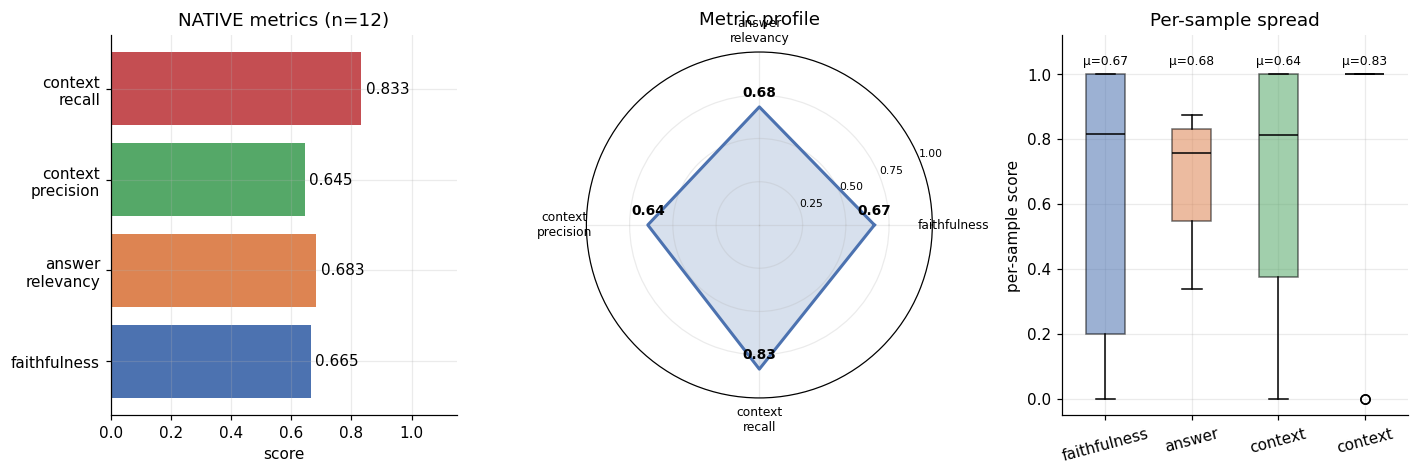

In [38]:
# ---- Figure 7: generation quality ----
order = ["faithfulness", "answer_relevancy", "context_precision", "context_recall"]
keys = [k for k in order if k in SCORES and not np.isnan(SCORES[k])]
vals = [SCORES[k] for k in keys]
if not keys:
    raise RuntimeError("no generation metrics available — re-run the previous two cells")

fig = plt.figure(figsize=(13, 4.4))
ax1 = fig.add_subplot(1, 3, 1)
b = ax1.barh([k.replace("_", "\n") for k in keys], vals, color=PALETTE[:len(keys)])
ax1.bar_label(b, fmt="%.3f", fontsize=10, padding=3)
ax1.set_xlim(0, 1.15); ax1.set_xlabel("score")
ax1.set_title(f"{EVAL_BACKEND.upper()} metrics (n={len(EVAL_DF)})")

ax2 = fig.add_subplot(1, 3, 2, polar=True)
ang = np.linspace(0, 2*np.pi, len(keys), endpoint=False).tolist()
vv = vals + vals[:1]; aa = ang + ang[:1]
ax2.plot(aa, vv, color=PALETTE[0], lw=2); ax2.fill(aa, vv, color=PALETTE[0], alpha=0.22)
ax2.set_xticks(ang); ax2.set_xticklabels([k.replace("_", "\n") for k in keys], fontsize=8)
ax2.set_ylim(0, 1); ax2.set_yticks([0.25, 0.5, 0.75, 1.0])
ax2.set_yticklabels(["0.25", "0.50", "0.75", "1.00"], fontsize=7)
for a, v in zip(ang, vals):
    ax2.annotate(f"{v:.2f}", xy=(a, v), xytext=(0, 7), textcoords="offset points",
                 fontsize=9, ha="center", fontweight="bold")
ax2.set_title("Metric profile", pad=18)

ax3 = fig.add_subplot(1, 3, 3)
if per_sample is not None and all(k in per_sample.columns for k in keys):
    data = [pd.to_numeric(per_sample[k], errors="coerce").dropna().values for k in keys]
    bp = ax3.boxplot(data, patch_artist=True, medianprops=dict(color="black"))
    ax3.set_xticks(range(1, len(keys) + 1))
    ax3.set_xticklabels([k.split("_")[0] for k in keys])
    for patch, col in zip(bp["boxes"], PALETTE):
        patch.set_facecolor(col); patch.set_alpha(0.55)
    for i, d in enumerate(data, 1):
        ax3.annotate(f"μ={d.mean():.2f}", xy=(i, 1.03), ha="center", fontsize=8)
    ax3.set_ylim(-0.05, 1.12); ax3.set_ylabel("per-sample score")
    ax3.set_title("Per-sample spread")
    ax3.tick_params(axis="x", rotation=15)

plt.tight_layout(); plt.savefig(f"{FIG_DIR}/fig7_ragas.png", bbox_inches="tight"); plt.show()
if per_sample is not None:
    per_sample.to_csv(os.path.join(WORK_DIR, "eval_generation_scored.csv"), index=False)

In [39]:
# ============================== ASK THE SYSTEM ==============================
QUERY = "Thời gian và kế hoạch đào tạo của chương trình tại học viện được tổ chức như thế nào?"

SHOW_PASSAGES = True
SHOW_TRACE    = True
PASSAGE_CHARS = 400

# ---------------------------------------------------------------------------
from IPython.display import Markdown, display as _display

# Every outcome is already decided inside answer_question(); this maps the trace
# it left behind onto a human-readable cause. Most specific match wins.
ABSTAIN_CAUSE = [
    ("ABSTAIN_after_verification", "answer failed groundedness verification"),
    ("reader_declined->ABSTAIN",   "reader judged the passages insufficient"),
    ("grade=insufficient",         "evidence graded insufficient after retry"),
    ("gate=below_threshold",       "retrieval confidence below τ"),
]


def explain(res: RagResult) -> Tuple[str, str]:
    if res.abstained:
        for token, cause in ABSTAIN_CAUSE:
            if any(token in step for step in res.trace):
                return "⛔ ABSTAINED", cause
        return "⛔ ABSTAINED", "unspecified"
    if res.route == "CHITCHAT":
        return "💬 DIRECT REPLY", "routed as conversational, no retrieval"
    return "✅ ANSWERED", f"grounded={res.grounded}, {res.rounds} retrieval round(s)"


def ask(query: str, show_passages: bool = True, show_trace: bool = True,
        top_k: int = FINAL_K, tau: Optional[float] = None) -> RagResult:
    tau = ANSWER_THRESHOLD if tau is None else tau      # 0.0 must stay 0.0
    res = answer_question(query, top_k=top_k, tau=tau)
    status, reason = explain(res)

    lines = [f"### {status}", f"**Q:** {res.question}", "", "---", "",
             res.answer, "", "---",
             f"`confidence {res.confidence:.3f}` vs `τ {tau:.3f}` · "
             f"`route {res.route}` · `{res.seconds:.1f}s` · {reason}"]

    if res.citations:
        lines += ["", "**Cited sources**", "",
                  "| # | document | page | rerank score |", "|---|---|---|---|"]
        lines += [f"| [{c['n']}] | {c['source']} | {c['page']} | {c['score']:.3f} |"
                  for c in res.citations]
    elif not res.abstained and res.route != "CHITCHAT":
        lines += ["", "_No inline citations produced — treat this answer with suspicion._"]

    _display(Markdown("\n".join(lines)))

    if show_passages and res.hits:
        print("\n" + "=" * 92)
        print("RETRIEVED PASSAGES (what the reader actually saw)")
        print("=" * 92)
        for i, h in enumerate(res.hits, 1):
            mark = "★ cited" if any(c["n"] == i for c in res.citations) else "  unused"
            print(f"\n[{i}] {mark} | score {h.score:.3f} | {h.chunk.source} — page {h.chunk.page}")
            print("    " + h.chunk.text[:PASSAGE_CHARS].replace("\n", "\n    ") + "…")

    if show_trace:
        print("\ntrace: " + " → ".join(res.trace))

    return res


result = ask(QUERY, show_passages=SHOW_PASSAGES, show_trace=SHOW_TRACE)

### ✅ ANSWERED
**Q:** Thời gian và kế hoạch đào tạo của chương trình tại học viện được tổ chức như thế nào?

---

Theo quy định, thời gian và kế hoạch đào tạo của chương trình tại học viện được tổ chức theo khóa học, năm học và học kỳ. Kế hoạch triển khai tổ chức đào tạo được quy định cho từng kỳ học, năm học và toàn khóa học [1]. Thời gian cụ thể đối với hình thức đào tạo chính quy như sau: từ 4 đến 5 năm đối với người có bằng tốt nghiệp trung học phổ thông (bao gồm cả thời gian huấn luyện đầu khóa), và từ 2,5 năm đến 3 năm đối với người tốt nghiệp trung cấp đủ điều kiện theo quy định [1].

---
`confidence 0.984` vs `τ 0.055` · `route SIMPLE` · `57.5s` · grounded=True, 1 retrieval round(s)

**Cited sources**

| # | document | page | rerank score |
|---|---|---|---|
| [1] | quy-che-hoc-tap.pdf | 1 | 0.984 |


RETRIEVED PASSAGES (what the reader actually saw)

[1] ★ cited | score 0.984 | quy-che-hoc-tap.pdf — page 1
    QUY CHẾ 
    Đào tạo trình độ đại học hệ Công an 
    của Học viện Kỹ thuật và Công nghệ an ninh 
     (Ban hành kèm theo Quyết định số: /QĐ-T07-P3 ngày / /2026 
    của Giám đốc Học viện Kỹ thuật và Công nghệ an ninh)
    
    Chương I NHỮNG QUY ĐỊNH CHUNG Điều 1. Phạm vi điều chỉnh và đối tượng áp dụng 1. Quy chế này quy định về tổ chức và quản lý đào tạo trình độ đại học, bao gồm: Chương trình đào tạo và thời gian học…

[2]   unused | score 0.918 | quy-che-hoc-tap.pdf — page 3
    cùng học viên khóa sau để học lại các học phần chưa đạt theo quy định trong
    
    chương trình đào tạo.
    
    Điều 5. Hình thức đào tạo
    
    1. Đào tạo chính quy:
    
    a) Các hoạt động giảng dạy được thực hiện tại Học viện, riêng những hoạt
    
    động thực hành, thực tập, trải nghiệm thực tế và giảng dạy trực tuyến có thể thực
    
    hiện ngoài Học viện.
    
    b) Thời gian 

---
# §20 Cost profile

Accuracy that cannot be served is not useful. This section measures where the time goes and
how many language-model calls the design actually costs, so that the tradeoffs argued for
above can be checked against a budget rather than asserted.

The reranker is expected to dominate first-stage retrieval latency, and the language-model
stages to dominate everything. The routing, grading and verification calls are what a
single-shot pipeline saves — and what buys the abstention and self-correction behaviour.

,mean ms,p90 ms,share %
generate (LLM),21365.9,28283.8,47.0
verify (LLM),14580.4,16245.6,32.1
grade (LLM),5070.9,5426.3,11.2
cross-encoder rerank,3329.8,3462.1,7.3
route (LLM),1072.8,1090.5,2.4
dense search,21.4,22.6,0.0
bm25 search,8.3,10.4,0.0
rrf fusion,0.1,0.1,0.0


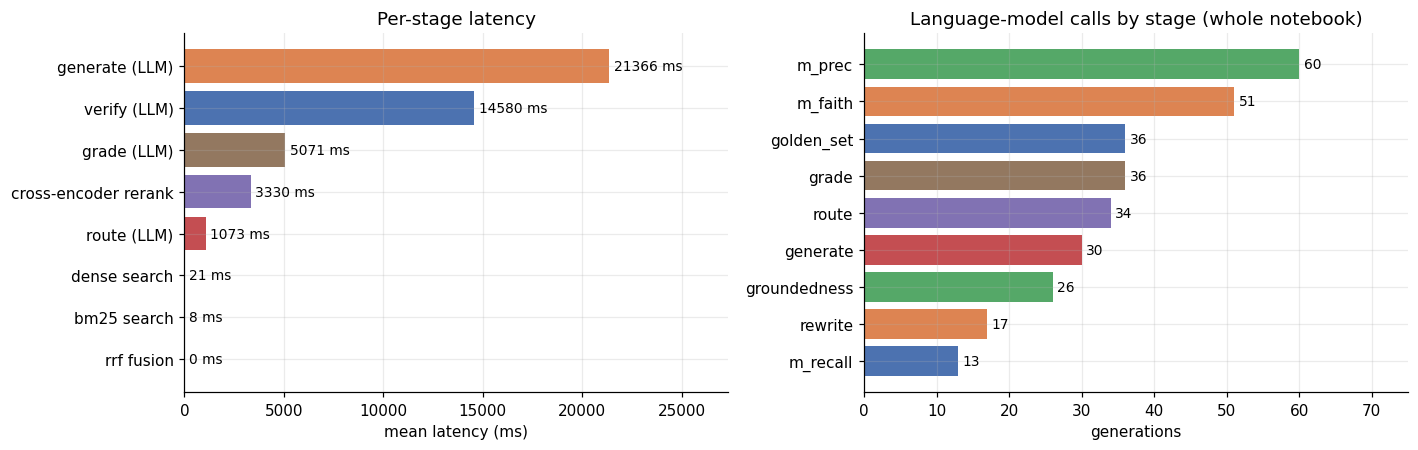

total LLM generations in this run: 341


In [40]:
probe = [d["question"] for d in INDOMAIN[:6]]
stage_times = defaultdict(list)

for q in probe:
    t = time.time(); dv = dense_struct.search(q, CANDIDATES_K); stage_times["dense search"].append(time.time()-t)
    t = time.time(); sv = sparse.search(q, CANDIDATES_K);       stage_times["bm25 search"].append(time.time()-t)
    t = time.time(); cand = rrf_fuse(dv, sv, top_n=CANDIDATES_K); stage_times["rrf fusion"].append(time.time()-t)
    t = time.time(); hits = rerank(q, cand, FINAL_K);            stage_times["cross-encoder rerank"].append(time.time()-t)
    t = time.time(); route_query(q);                             stage_times["route (LLM)"].append(time.time()-t)
    t = time.time(); grade_sufficiency(q, hits);                 stage_times["grade (LLM)"].append(time.time()-t)
    ctx = build_context(hits)
    t = time.time(); a = generate_answer(q, hits);               stage_times["generate (LLM)"].append(time.time()-t)
    t = time.time(); check_grounded(a, ctx);                     stage_times["verify (LLM)"].append(time.time()-t)

lat = pd.DataFrame({"mean ms": {k: np.mean(v)*1000 for k, v in stage_times.items()},
                    "p90 ms":  {k: np.percentile(v, 90)*1000 for k, v in stage_times.items()}})
lat["share %"] = 100 * lat["mean ms"] / lat["mean ms"].sum()
lat = lat.sort_values("mean ms", ascending=False)
display(lat.style.format("{:.1f}"))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
b = axes[0].barh(lat.index[::-1], lat["mean ms"][::-1],
                 color=[PALETTE[i % len(PALETTE)] for i in range(len(lat))])
axes[0].bar_label(b, fmt="%.0f ms", fontsize=9, padding=3)
axes[0].set_xlim(0, lat["mean ms"].max() * 1.28)
axes[0].set_xlabel("mean latency (ms)"); axes[0].set_title("Per-stage latency")

calls = pd.Series(LLM_CALLS).sort_values(ascending=False).head(9)
b2 = axes[1].barh(calls.index[::-1], calls.values[::-1],
                  color=[PALETTE[i % len(PALETTE)] for i in range(len(calls))])
axes[1].bar_label(b2, fmt="%d", fontsize=9, padding=3)
axes[1].set_xlim(0, calls.max() * 1.25)
axes[1].set_xlabel("generations"); axes[1].set_title("Language-model calls by stage (whole notebook)")

plt.tight_layout(); plt.savefig(f"{FIG_DIR}/fig8_cost.png", bbox_inches="tight"); plt.show()
print(f"total LLM generations in this run: {sum(LLM_CALLS.values()):,}")

---
# §21 Persistence

The offline stage is expensive and deterministic, so it is cached. Chunks, dense embeddings,
the calibrated threshold and the full run configuration are written to disk; the BM25 index
rebuilds from the chunks in seconds and is not worth serialising. Storing the threshold and
model identifiers alongside the vectors matters: an index built with one encoder and a
threshold fitted against another would silently mis-calibrate the abstention gate.

In [41]:
np.save(os.path.join(INDEX_DIR, "dense_structural.npy"), dense_struct.emb)
if dense_ctx is not None:
    np.save(os.path.join(INDEX_DIR, "dense_llmcontext.npy"), dense_ctx.emb)
with open(os.path.join(INDEX_DIR, "chunks.pkl"), "wb") as f:
    pickle.dump([asdict(c) for c in CHUNKS], f)

MANIFEST = {
    "embedding_model": EMBEDDING_MODEL, "reranker_model": RERANKER_MODEL,
    "reader_model": READER_MODEL, "baseline_model": BASELINE_MODEL,
    "n_chunks": len(CHUNKS), "n_pages": len(PAGES),
    "chunk_tokens": CHUNK_TOKENS, "chunk_overlap": CHUNK_OVERLAP,
    "llm_contextualised": bool(USE_LLM_CONTEXT),
    "candidates_k": CANDIDATES_K, "final_k": FINAL_K, "rrf_k": RRF_K,
    "answer_threshold": round(float(ANSWER_THRESHOLD), 4),
    "threshold_f1": round(float(TAU_F1), 4), "threshold_safe": round(float(TAU_SAFE), 4),
    "eval_backend": EVAL_BACKEND, "generation_scores": {k: round(v, 4) for k, v in SCORES.items()},
    "retrieval_ablation": {k: {m: round(v, 4) for m, v in s.items()} for k, s in results.items()},
    "sources": [os.path.basename(p) for p in DATA_FILES],
    "seed": SEED,
}
with open(os.path.join(INDEX_DIR, "manifest.json"), "w", encoding="utf-8") as f:
    json.dump(MANIFEST, f, ensure_ascii=False, indent=2)


def load_index(index_dir: str = INDEX_DIR):
    with open(os.path.join(index_dir, "manifest.json"), encoding="utf-8") as f:
        manifest = json.load(f)
    with open(os.path.join(index_dir, "chunks.pkl"), "rb") as f:
        chunks = [Chunk(**d) for d in pickle.load(f)]
    emb = np.load(os.path.join(index_dir, "dense_structural.npy"))
    return manifest, chunks, emb


m, c, e = load_index()
print(json.dumps(m, ensure_ascii=False, indent=2)[:900])
print(f"\nreload check: {len(c)} chunks, embeddings {e.shape}")
print("artefacts:", sorted(os.listdir(INDEX_DIR)), "|", sorted(os.listdir(FIG_DIR)))

{
  "embedding_model": "BAAI/bge-m3",
  "reranker_model": "BAAI/bge-reranker-v2-m3",
  "reader_model": "Qwen/Qwen2.5-7B-Instruct",
  "baseline_model": "thenlper/gte-small",
  "n_chunks": 1116,
  "n_pages": 639,
  "chunk_tokens": 400,
  "chunk_overlap": 60,
  "llm_contextualised": false,
  "candidates_k": 30,
  "final_k": 5,
  "rrf_k": 60,
  "answer_threshold": 0.055,
  "threshold_f1": 0.055,
  "threshold_safe": 0.055,
  "eval_backend": "native",
  "generation_scores": {
    "faithfulness": 0.6653,
    "answer_relevancy": 0.6825,
    "context_precision": 0.6449,
    "context_recall": 0.8333
  },
  "retrieval_ablation": {
    "A · gte-small dense": {
      "recall@5": 0.5,
      "mrr@10": 0.4345
    },
    "B · bge-m3 dense": {
      "recall@5": 0.8889,
      "mrr@10": 0.7168
    },
    "C · + BM25 (whitespace)": {
      "recall@5": 0.9444,
      "mrr@10": 0.7475
    },
    "D · + BM25 (py

reload check: 1116 chunks, embeddings (1116, 1024)
artefacts: ['chunks.pkl', 'dense_structural.npy

In [42]:
# ---- Consolidated results table ----
summary = pd.DataFrame({
    "metric": (["recall@5 · " + k.split("·")[0].strip() for k in results] +
               ["abstention · " + k for k in ["precision", "recall", "F1", "OOD rejection"]] +
               [f"{EVAL_BACKEND} · " + k for k in SCORES]),
    "value":  ([results[k]["recall@5"] for k in results] +
               [held["precision"], held["recall"], held["f1"], held["ood_rejection"]] +
               [SCORES[k] for k in SCORES]),
})
summary.to_csv(os.path.join(WORK_DIR, "summary.csv"), index=False)
display(summary.style.format({"value": "{:.3f}"}).hide(axis="index"))

metric,value
recall@5 · A,0.500
recall@5 · B,0.889
recall@5 · C,0.944
recall@5 · D,0.944
recall@5 · E,0.972
abstention · precision,0.947
abstention · recall,1.000
abstention · F1,0.973
abstention · OOD rejection,0.917
native · faithfulness,0.665


---
# §22 Discussion, limitations and further work

## Findings

**RQ1 — encoder language coverage dominates everything else.** The A→B step in Figure 2, and
its language breakdown in Figure 3, isolate the largest single effect in the pipeline. A
monolingual encoder applied to out-of-distribution script does not degrade gracefully; it
produces embeddings with no usable structure, and no amount of reranking or prompt engineering
downstream recovers a passage that first-stage retrieval never surfaced. Encoder choice should
be settled before any other tuning is attempted.

**RQ2 — lexical retrieval remains complementary, and segmentation is a prerequisite.** The
C→D step measures word segmentation specifically. Because Vietnamese orthography separates
syllables rather than words, an unsegmented BM25 index matches fragments and contributes noise
to the fusion; segmented, it recovers exactly the queries dense retrieval handles worst.

**RQ3 — reranking is the best accuracy-per-line change available**, and Figure 8 shows it is
also the dominant retrieval-side latency cost. The tradeoff is favourable here but is a
deployment decision, not a universal one.

**RQ4 — LLM contextualisation has a smaller marginal effect than reported elsewhere**,
because the deterministic structural prefix already supplies much of the same signal at zero
cost. The gap should widen on corpora with heavy cross-referencing and dense tables.

**RQ5 — abstention is learnable from a small negative set.** Figure 4 shows the cross-encoder
score separates answerable from unanswerable questions well enough to threshold, and Figure 5
reports the operating point on held-out data. This is the finding with the most practical
weight: refusal behaviour is usually left to prompt instructions, and prompt instructions are
soft constraints that a sufficiently confident-sounding question can override. A threshold
evaluated before generation cannot be.

**RQ6 — the retry loop recovers a minority of cases** but costs a grading call on every query.
Its value is highest when query phrasing diverges from document vocabulary, which is precisely
the regime hand-written evaluation questions probe and synthetic ones do not.

## Limitations

**The judge is the generator.** RAGAS metrics in §19 are computed with the same model that
produced the answers. Self-evaluation is biased toward approval, so the absolute values are
optimistic; only comparisons between configurations scored the same way are trustworthy.

**The evaluation set is largely synthetic.** Questions generated from a passage reuse its
vocabulary, which inflates lexical retrieval and understates the difficulty of paraphrase.
The `HANDWRITTEN` list in §12 exists to correct this and should be populated before any
result is reported externally.

**One relevant passage per question.** Recall@5 assumes a single gold chunk. Questions
answerable from several passages, or requiring synthesis across them, are scored incorrectly
by this definition.

**The out-of-domain set is easy.** Cooking and geography questions are far from the corpus in
embedding space. The harder and more realistic case is *near*-domain: questions about cloud
computing that this particular document happens not to cover. The threshold fitted here will
be optimistic against those, and extending the OOD set with near-miss questions is the single
most valuable improvement to the evaluation.

**Small samples.** With a few dozen questions per configuration, differences below roughly
0.10 in recall@5 are within noise. Bootstrap confidence intervals, or simply a larger
evaluation set, are needed before ranking closely-spaced configurations.

**Text only.** Tables are flattened into text and figures are discarded entirely. For
diagram-heavy technical documents this loses precisely the information the document exists to
convey.

## Further work

**Near-domain abstention.** Extend the OOD set with questions adjacent to the corpus topics
and re-fit τ. Expect the threshold to rise and false abstentions with it — that tension is the
real research question hiding behind the gate.

**Multi-vector and late-interaction retrieval.** BGE-M3 additionally emits learned sparse
weights and ColBERT-style token vectors from the same forward pass, accessible through
`FlagEmbedding`. Both are natural additional ablation rows.

**Visual retrieval.** ColPali-family models embed rendered page images directly, removing the
parsing and OCR stages altogether. For scanned or diagram-heavy documents this is likely to
outperform the entire text pipeline built here.

**Independent judging.** Score generation with a model from a different family than the
reader to remove the self-evaluation bias.

**Bootstrapped intervals.** Resample the evaluation set to attach confidence intervals to
every value in Figures 2, 3 and 7, so that the ablation supports claims about ordering rather
than merely displaying it.